# What sequence grammar does the seq-only CAGEAN learn?

**Model.** `SeqOnlyTransformer` (exp29) — 1000 bp one-hot DNA → `Conv1d(4→64, k=10, stride=10)`
→ 100 tokens → 4 pre-norm Transformer layers (4 heads, d=64) → mean-pool → linear logit.
Trained on A549 G4P, binarised at `Q = 0.0408277148` (top ~5%).

**The question.** *Both* classes contain regex-defined PQSs. So the model cannot be
separating "PQS" from "no PQS". What distinguishes a **top-5% G4P PQS** from an
ordinary one?

**Design note — what makes this non-circular.** Every sequence analysed here is a PQS
window. PQS presence is held constant by construction, so any feature that separates the
classes is a feature *beyond* the regex.

| § | Analysis | Evidence type |
|---|---|---|
| 1 | Per-base saturation mutagenesis | causal, on real sequence |
| 2 | Synthetic perturbation | causal, on controlled sequence |
| 3 | Layerwise probing | correlational, localises the code |
| 4 | Attention | correlational, supporting only |

Sections 1–2 carry the causal claims. Sections 3–4 say *where* and *how* the rules are
represented — they support, never establish, importance.

---
## 0. Setup

Run with the env that has torch:

```bash
/home/brx8wc/.conda/envs/dnabert2_modern_env/bin/python -m jupyter lab
```

GPU strongly recommended (`srun --partition=gpu --gres=gpu:1 --cpus-per-task=8 --mem=64G --pty bash`).
The notebook runs on CPU but ISM over many sequences will be slow.

In [2]:
import os, sys, json, math, time, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score, r2_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

torch 1.13.1+cu117 | device: cpu


In [3]:
# ── Paths (verified to exist on this filesystem) ──────────────────────────────
REPO     = Path("/home/brx8wc/CAGEAN_Repo/CAGEAN")
CKPT     = Path("/project/cphg-RLstore/G4/aakrosh/experiments/exp29_seqonly/models/seqonly/best_model.pt")
TEST_DIR = Path("/project/cphg-RLstore/G4/aakrosh/data/inputs_numpy/test_1000nt")
PQS_BED  = Path("/project/cphg-RLstore/G4/data/PQS_unpadded.bed")   # exact PQS coords
PAD_BED  = Path("/project/cphg-RLstore/G4/data/PQS_padded_1kb.bed") # the 1 kb window
OUT      = Path("/home/brx8wc/G4/interp_seqonly/results"); OUT.mkdir(parents=True, exist_ok=True)
FIGS     = OUT / "figures"; FIGS.mkdir(exist_ok=True)

Q_A549      = 4.08277148e-02   # top-5% G4P threshold used in training
TEST_CHROMS = ["chr1", "chr3", "chr5", "chr7", "chr9"]
L           = 1000             # window length
STEM_K      = 10               # conv stride → 100 tokens
N_TOK       = L // STEM_K

# One-hot channel order is A,T,C,G  (data_prep/02_extract_epi_signal.py) — NOT ACGT.
BASES   = ["A", "T", "C", "G"]
B2I     = {b: i for i, b in enumerate(BASES)}
G_IDX, C_IDX = B2I["G"], B2I["C"]

for p in [CKPT, TEST_DIR, PQS_BED, PAD_BED]:
    assert p.exists(), f"missing: {p}"
print("all paths OK")

all paths OK


### Plot style

In [4]:
sns.set_theme(style="ticks", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
    "font.family": "DejaVu Sans", "legend.frameon": False,
})

# Base colours held fixed everywhere a nucleotide is drawn.
BASE_COLORS = {"A": "#3B7DD8", "T": "#E8833A", "C": "#4FA46A", "G": "#C7443B"}
POS_C, NEG_C, NEU_C = "#C7443B", "#4B6BAF", "#9AA0A6"
DIVERGE = "RdBu_r"

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png")
    fig.savefig(FIGS / f"{name}.svg")
    print("saved →", FIGS / f"{name}.png")

---
## 1. Model and data

### 1.1 Load the trained model

In [5]:
sys.path.insert(0, str(REPO))
from models.seqonly_transformer import SeqOnlyTransformer

model = SeqOnlyTransformer(d_model=64, nhead=4, num_layers=4,
                           dim_feedforward=192, stem_kernel=STEM_K, dropout=0.0)
state = torch.load(CKPT, map_location="cpu")
missing, unexpected = model.load_state_dict(state, strict=True), None
model.eval().to(DEVICE)
for p in model.parameters():
    p.requires_grad_(False)

n_par = sum(p.numel() for p in model.parameters())
print(f"loaded {CKPT.name}  |  {n_par:,} params  |  eval mode, grads off")

loaded best_model.pt  |  169,857 params  |  eval mode, grads off


> **BatchNorm caveat.** The stem contains a `BatchNorm1d`. In `.eval()` it uses running
> statistics, so predictions are independent of batch composition — required for ISM to be
> meaningful. Every inference below runs under `model.eval()`.

In [6]:
@torch.no_grad()
def predict_logits(x, batch=2048):
    """x: (N,4,1000) float/int array or tensor → (N,) logits."""
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(np.ascontiguousarray(x))
    out = []
    for i in range(0, len(x), batch):
        xb = x[i:i+batch].float().to(DEVICE, non_blocking=True)
        out.append(model(xb).squeeze(1).float().cpu())
    return torch.cat(out).numpy()

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Determinism check: same input twice → identical logits.
_probe = np.load(TEST_DIR / "chr1_seqs.npy", mmap_mode="r")[:512]
_a, _b = predict_logits(_probe), predict_logits(_probe)
assert np.allclose(_a, _b, atol=1e-6), "model is not deterministic in eval mode!"
print(f"determinism OK   logit range on 512 probe seqs: [{_a.min():.2f}, {_a.max():.2f}]")

determinism OK   logit range on 512 probe seqs: [-8.36, 4.85]


### 1.2 Load test sequences and PQS coordinates

`{chrom}_pqs_ids.txt` is row-aligned with `{chrom}_seqs.npy`. The IDs carry the PI's
three-way PQS class (`ce` canonical / `bu` bulged / `irr` irregular). The BED files use a
different suffix convention, so the join is on the **numeric ID** only — verified below to
be exact.

In [7]:
def load_pqs_bed():
    """Numeric pqs id → (chrom, pqs_start, pqs_end, strand, window_start)."""
    unp = pd.read_csv(PQS_BED, sep="\t", header=None,
                      names=["chrom", "start", "end", "name", "score", "strand"])
    pad = pd.read_csv(PAD_BED, sep="\t", header=None,
                      names=["chrom", "start", "end", "name", "score", "strand"])
    same = len(unp) == len(pad) and (unp["name"].values == pad["name"].values).all()
    assert same, "unpadded/padded BEDs are not row-matched"
    unp["pid"] = unp["name"].str.split("_").str[0]
    unp["win_start"] = pad["start"].values
    unp["win_end"]   = pad["end"].values
    return unp.set_index("pid")

pqs_bed = load_pqs_bed()
print(f"PQS BED: {len(pqs_bed):,} records")
pqs_bed.head(3)

PQS BED: 2,207,475 records


,chrom,start,end,name,score,strand,win_start,win_end
pid,,,,,,,,
pqs121435,chr1,10003,10149,pqs121435_b,.,-,9576,10576
pqs89677,chr1,10003,10497,pqs89677_ce,.,-,9750,10750
pqs121436,chr1,10153,10174,pqs121436_b,.,-,9663,10663


In [8]:
def load_chrom(chrom):
    """Return dict with seqs (N,4,1000) int8, G4P signal, binary label, PQS offsets."""
    seqs   = np.load(TEST_DIR / f"{chrom}_seqs.npy")          # (N,4,1000) int8
    signal = np.load(TEST_DIR / f"{chrom}_labels.npy")        # continuous G4P
    ids    = [l.strip() for l in open(TEST_DIR / f"{chrom}_pqs_ids.txt")]
    assert len(ids) == len(seqs) == len(signal)

    pid = pd.Series(ids).str.split("_").str[0].values
    cls = pd.Series(ids).str.split("_").str[1].values          # ce / bu / irr
    sub = pqs_bed.reindex(pid)
    assert sub["chrom"].notna().all(), f"{chrom}: unmatched PQS ids"

    # PQS position *within* the 1 kb window
    pqs_s = (sub["start"].values - sub["win_start"].values).astype(int)
    pqs_e = (sub["end"].values   - sub["win_start"].values).astype(int)

    return dict(chrom=chrom, seqs=seqs, signal=signal,
                label=(signal > Q_A549).astype(np.int8),
                pqs_id=pid, pqs_class=cls, strand=sub["strand"].values,
                pqs_start=pqs_s, pqs_end=pqs_e)

t0 = time.time()
D1 = load_chrom("chr1")
print(f"chr1: {len(D1['seqs']):,} windows in {time.time()-t0:.1f}s  "
      f"pos={D1['label'].mean()*100:.2f}%")
print("PQS class mix:", pd.Series(D1["pqs_class"]).value_counts().to_dict())

chr1: 184,024 windows in 5.9s  pos=4.46%
PQS class mix: {'bu': 79692, 'irr': 56153, 'ce': 48179}


#### Sanity check the coordinate join

If the offsets are right, the PQS should sit near the centre of the window and the
sequence under it should be G-rich (or C-rich on the minus strand, since the one-hot is
always plus-strand genomic).

In [9]:
pqs_len = D1["pqs_end"] - D1["pqs_start"]
pqs_mid = (D1["pqs_start"] + D1["pqs_end"]) / 2
inside  = (D1["pqs_start"] >= 0) & (D1["pqs_end"] <= L)

print(f"PQS length   median={np.median(pqs_len):.0f}  IQR=({np.percentile(pqs_len,25):.0f}"
      f", {np.percentile(pqs_len,75):.0f})  max={pqs_len.max()}")
print(f"PQS midpoint median={np.median(pqs_mid):.1f}  (window centre = {L/2:.0f})")
print(f"fully inside window: {inside.mean()*100:.2f}%")

# G content inside vs outside the annotated PQS, on a sample.
# A few PQSs span nearly the whole window (max length above), leaving no flank —
# those are skipped rather than contributing an empty-slice NaN.
n_s  = min(3000, len(D1["seqs"]))
ss   = np.random.default_rng(0).choice(len(D1["seqs"]), n_s, replace=False)
gin, gout, skipped = [], [], 0
for i in ss:
    s, e = max(0, int(D1["pqs_start"][i])), min(L, int(D1["pqs_end"][i]))
    m = np.zeros(L, bool); m[s:e] = True
    if m.sum() < 10 or (~m).sum() < 10:      # need both regions to be non-trivial
        skipped += 1
        continue
    g = D1["seqs"][i][G_IDX].astype(np.float32)
    gin.append(g[m].mean()); gout.append(g[~m].mean())

gin_m, gout_m = float(np.mean(gin)), float(np.mean(gout))
print(f"\nG fraction  inside PQS = {gin_m:.3f}   outside PQS = {gout_m:.3f}"
      f"   (n={len(gin)}, skipped {skipped} with no usable flank)")
assert np.isfinite(gin_m) and np.isfinite(gout_m), "G-content check produced NaN"
assert gin_m > gout_m, "join looks wrong — PQS interior is not G-enriched"
print("coordinate join verified ✓")

PQS length   median=26  IQR=(22, 33)  max=1498
PQS midpoint median=500.0  (window centre = 500)
fully inside window: 100.00%

G fraction  inside PQS = 0.516   outside PQS = 0.257   (n=3000, skipped 0 with no usable flank)
coordinate join verified ✓


### 1.3 Reproduce the published metric

Before interpreting the model we confirm it behaves as reported: **A549 test AUPRC 0.7257**
(from the exp29 eval log). This guards against a silent mismatch in one-hot channel order,
threshold, or checkpoint.

In [10]:
def eval_chroms(chroms=TEST_CHROMS):
    ys, ps = [], []
    for c in chroms:
        seqs = np.load(TEST_DIR / f"{c}_seqs.npy", mmap_mode="r")
        sig  = np.load(TEST_DIR / f"{c}_labels.npy")
        ps.append(predict_logits(np.asarray(seqs)))
        ys.append((sig > Q_A549).astype(np.int8))
        print(f"  {c}: {len(sig):,}")
    return np.concatenate(ys), np.concatenate(ps)

y_test, logit_test = eval_chroms()
auprc = average_precision_score(y_test, logit_test)
auroc = roc_auc_score(y_test, logit_test)
print(f"\nA549 test  n={len(y_test):,}  pos={y_test.mean()*100:.1f}%")
print(f"  AUPRC = {auprc:.4f}   (published: 0.7257)")
print(f"  AUROC = {auroc:.4f}")
np.save(OUT / "test_logits.npy", logit_test); np.save(OUT / "test_labels.npy", y_test)

KeyboardInterrupt: 

> ⚠️ **Checkpoint gate.** If AUPRC is not ≈0.726, stop — something upstream is wrong and
> every downstream conclusion would be built on a mis-wired model.

In [ ]:
assert abs(auprc - 0.7257) < 0.02, f"AUPRC {auprc:.4f} != published 0.7257 — investigate before continuing"
print("✓ model reproduces the published metric; proceeding")

### 1.4 The baseline the model must beat

The whole premise is that the model knows more than "there is a PQS here". So we first
measure how far trivial sequence statistics get. **These numbers are the bar** every later
claim is judged against.

In [11]:
def seq_features(seqs, pqs_start, pqs_end, chunk=20000):
    """Cheap interpretable features per window."""
    feats = defaultdict(list)
    for i0 in range(0, len(seqs), chunk):
        oh = np.asarray(seqs[i0:i0+chunk]).astype(np.float32)   # (n,4,L)
        n  = len(oh)
        g, c = oh[:, G_IDX], oh[:, C_IDX]
        feats["G_frac"].append(g.mean(1))
        feats["C_frac"].append(c.mean(1))
        feats["GC_frac"].append((g + c).mean(1))
        feats["G_skew"].append((g.sum(1) - c.sum(1)) / (g.sum(1) + c.sum(1) + 1e-6))
        # max G-run length + number of G>=3 runs, per sequence
        mx, n3 = np.zeros(n), np.zeros(n)
        for j in range(n):
            gg = g[j] > 0.5
            if not gg.any():
                continue
            d = np.diff(np.concatenate(([0], gg.view(np.int8), [0])))
            st, en = np.where(d == 1)[0], np.where(d == -1)[0]
            runs = en - st
            mx[j] = runs.max(); n3[j] = (runs >= 3).sum()
        feats["max_G_run"].append(mx); feats["n_G3_runs"].append(n3)
    out = {k: np.concatenate(v) for k, v in feats.items()}
    out["pqs_len"] = (pqs_end - pqs_start).astype(np.float32)
    return pd.DataFrame(out)

t0 = time.time()
F1 = seq_features(D1["seqs"], D1["pqs_start"], D1["pqs_end"])
print(f"features for chr1 in {time.time()-t0:.0f}s"); F1.head(3)

features for chr1 in 20s


,G_frac,C_frac,GC_frac,G_skew,max_G_run,n_G3_runs,pqs_len
0,0.346,0.107,0.453,0.527594,4.0,81.0,18.0
1,0.306,0.381,0.687,-0.109170,7.0,15.0,26.0
2,0.347,0.357,0.704,-0.014205,7.0,20.0,44.0


In [12]:
y1 = D1["label"]
p1 = predict_logits(D1["seqs"])

rows = []
for f in F1.columns:
    rows.append(dict(feature=f, AUPRC=average_precision_score(y1, F1[f]),
                     AUROC=roc_auc_score(y1, F1[f])))

# all simple features together (logistic regression, held-out half)
Xtr, Xte, ytr, yte = train_test_split(F1.values, y1, test_size=0.5,
                                      random_state=SEED, stratify=y1)
sc = StandardScaler().fit(Xtr)
lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(sc.transform(Xtr), ytr)
sp = lr.decision_function(sc.transform(Xte))
rows.append(dict(feature="ALL simple feats (LR)", AUPRC=average_precision_score(yte, sp),
                 AUROC=roc_auc_score(yte, sp)))
rows.append(dict(feature="★ SeqOnlyTransformer", AUPRC=average_precision_score(y1, p1),
                 AUROC=roc_auc_score(y1, p1)))

base = pd.DataFrame(rows).sort_values("AUPRC")
base.to_csv(OUT / "baseline_comparison.csv", index=False)
base

,feature,AUPRC,AUROC
3,G_skew,0.038746,0.454349
6,pqs_len,0.044833,0.497001
4,max_G_run,0.080514,0.711787
5,n_G3_runs,0.197884,0.867231
0,G_frac,0.252096,0.903969
1,C_frac,0.365469,0.913270
2,GC_frac,0.483726,0.957426
7,ALL simple feats (LR),0.510865,0.960089
8,★ SeqOnlyTransformer,0.702076,0.983073


saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig0_baselines.png


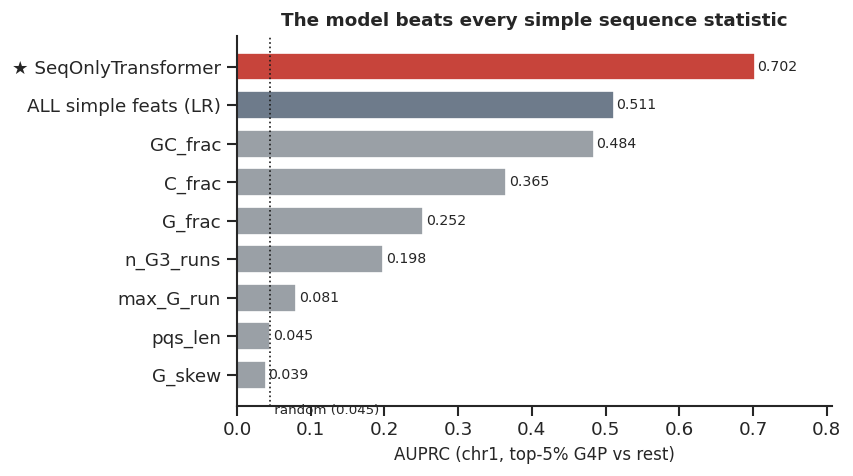

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
cols = [POS_C if "★" in f else ("#6E7B8B" if "ALL" in f else NEU_C) for f in base["feature"]]
ax.barh(base["feature"], base["AUPRC"], color=cols, height=.72)
ax.axvline(y1.mean(), ls=":", c="k", lw=1)
ax.text(y1.mean(), -0.75, f" random ({y1.mean():.3f})", fontsize=8, va="top")
for i, v in enumerate(base["AUPRC"]):
    ax.text(v + .004, i, f"{v:.3f}", va="center", fontsize=8.5)
ax.set_xlabel("AUPRC (chr1, top-5% G4P vs rest)")
ax.set_title("The model beats every simple sequence statistic")
ax.set_xlim(0, max(base["AUPRC"]) * 1.15)
save(fig, "fig0_baselines"); plt.show()

**Read this first.** The gap between ★ and *ALL simple feats* is the part of the model's
skill that composition, G-run counts and PQS length cannot explain. That gap is what
sections 1–2 are trying to name. If the gap were ~0 there would be no grammar to find.

---
## 2. Per-base saturation mutagenesis (ISM)

> **Which individual nucleotides causally drive the prediction?**

For every position $i$ and every alternative base $b$:

$$\Delta_{i,b} = \operatorname{logit}(x^{i \to b}) - \operatorname{logit}(x)$$

`3000 mutants/sequence`. This is a **causal** measure on the trained function — no
gradient approximation.

We sample a matched set: top-5% positives and, as the informative control, **negatives
that also contain a PQS** (all of them do). The contrast is therefore *strong PQS vs weak
PQS*, never *PQS vs no PQS*.

In [14]:
N_ISM = 300          # per class; raise to 1000+ on GPU for publication figures
rng   = np.random.default_rng(SEED)

pos_idx = np.where(y1 == 1)[0]
neg_idx = np.where(y1 == 0)[0]
# restrict to windows whose PQS is fully inside, so alignment is well defined
ok = (D1["pqs_start"] >= 0) & (D1["pqs_end"] <= L) & ((D1["pqs_end"] - D1["pqs_start"]) <= 300)
pos_idx = pos_idx[ok[pos_idx]]; neg_idx = neg_idx[ok[neg_idx]]

sel_pos = rng.choice(pos_idx, min(N_ISM, len(pos_idx)), replace=False)
sel_neg = rng.choice(neg_idx, min(N_ISM, len(neg_idx)), replace=False)
print(f"ISM on {len(sel_pos)} positives + {len(sel_neg)} negatives "
      f"= {(len(sel_pos)+len(sel_neg))*L*3:,} forward passes")

ISM on 300 positives + 300 negatives = 1,800,000 forward passes


In [15]:
@torch.no_grad()
def ism_one(oh, batch=3000):
    """oh: (4,L) int8 → (4,L) delta-logit; the reference base's own row is 0."""
    ref = torch.from_numpy(np.ascontiguousarray(oh)).float()
    base_logit = model(ref[None].to(DEVICE)).item()

    ref_idx = oh.argmax(0)                      # (L,) reference base per position
    muts, coord = [], []
    for pos in range(L):
        for b in range(4):
            if b == ref_idx[pos]:
                continue
            m = ref.clone(); m[:, pos] = 0.0; m[b, pos] = 1.0
            muts.append(m); coord.append((b, pos))
    muts = torch.stack(muts)

    out = np.zeros((4, L), np.float32)
    for i in range(0, len(muts), batch):
        lg = model(muts[i:i+batch].to(DEVICE)).squeeze(1).cpu().numpy()
        for (b, pos), v in zip(coord[i:i+batch], lg):
            out[b, pos] = v - base_logit
    return out, base_logit

In [16]:
def run_ism(indices, tag):
    cache = OUT / f"ism_{tag}.npz"
    if cache.exists():
        z = np.load(cache)
        print(f"loaded cached {cache.name}  {z['delta'].shape}")
        return z["delta"], z["base"], z["idx"]
    deltas, bases = [], []
    t0 = time.time()
    for k, i in enumerate(indices):
        d, bl = ism_one(D1["seqs"][i])
        deltas.append(d); bases.append(bl)
        if (k+1) % 25 == 0:
            el = time.time() - t0
            print(f"  {k+1}/{len(indices)}  {el:.0f}s elapsed  "
                  f"~{el/(k+1)*(len(indices)-k-1):.0f}s left", flush=True)
    deltas = np.stack(deltas); bases = np.array(bases)
    np.savez_compressed(cache, delta=deltas, base=bases, idx=indices)
    print(f"saved {cache.name}  ({time.time()-t0:.0f}s)")
    return deltas, bases, np.asarray(indices)

ism_pos, base_pos, idx_pos = run_ism(sel_pos, "pos")
ism_neg, base_neg, idx_neg = run_ism(sel_neg, "neg")
print("ISM tensors:", ism_pos.shape, ism_neg.shape)

  25/300  349s elapsed  ~3839s left
  50/300  679s elapsed  ~3397s left
  75/300  912s elapsed  ~2737s left
  100/300  1062s elapsed  ~2125s left
  125/300  1178s elapsed  ~1649s left
  150/300  1293s elapsed  ~1293s left
  175/300  1408s elapsed  ~1006s left
  200/300  1523s elapsed  ~762s left
  225/300  1638s elapsed  ~546s left
  250/300  1754s elapsed  ~351s left
  275/300  1869s elapsed  ~170s left
  300/300  1984s elapsed  ~0s left
saved ism_pos.npz  (1985s)
  25/300  115s elapsed  ~1269s left
  50/300  231s elapsed  ~1154s left
  75/300  346s elapsed  ~1037s left
  100/300  462s elapsed  ~923s left
  125/300  577s elapsed  ~807s left
  150/300  692s elapsed  ~692s left
  175/300  807s elapsed  ~577s left
  200/300  923s elapsed  ~461s left
  225/300  1038s elapsed  ~346s left
  250/300  1153s elapsed  ~231s left
  275/300  1268s elapsed  ~115s left
  300/300  1383s elapsed  ~0s left
saved ism_neg.npz  (1384s)
ISM tensors: (300, 4, 1000) (300, 4, 1000)


### 2.1 Importance inside vs outside the annotated PQS

The first question the plan asks: is the model reading the regex-defined PQS, or the
sequence around it? We use **per-position importance** = mean $|\Delta|$ over the three
possible substitutions.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig1a_in_vs_out_pqs.png


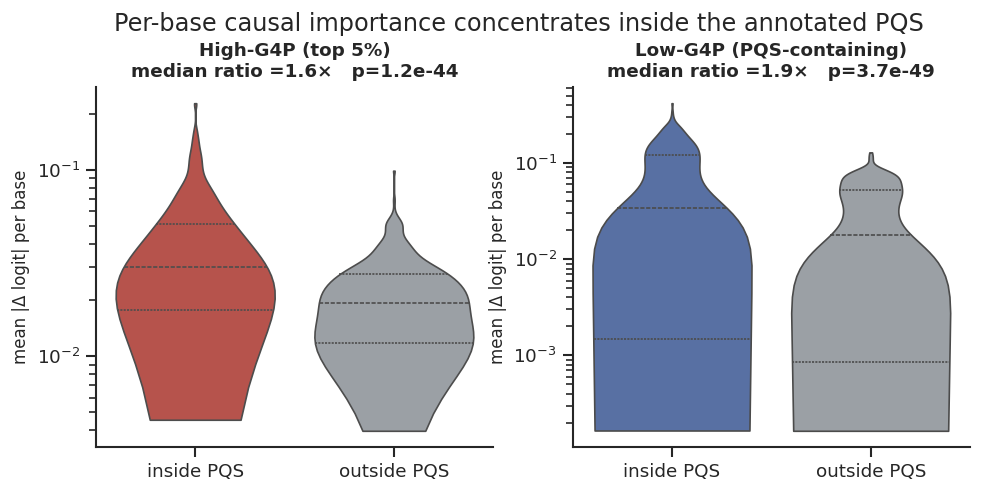

positives: inside/outside = 1.57×
negatives: inside/outside = 1.90×


In [17]:
def per_pos_importance(delta):
    """(N,4,L) → (N,L) mean |Δ| over the 3 non-reference bases."""
    return np.abs(delta).sum(1) / 3.0

imp_pos, imp_neg = per_pos_importance(ism_pos), per_pos_importance(ism_neg)

def in_out_split(imp, indices):
    ins, outs = [], []
    for r, i in enumerate(indices):
        s, e = D1["pqs_start"][i], D1["pqs_end"][i]
        m = np.zeros(L, bool); m[max(0,s):min(L,e)] = True
        if m.sum() < 5 or (~m).sum() < 5: continue
        ins.append(imp[r, m].mean()); outs.append(imp[r, ~m].mean())
    return np.array(ins), np.array(outs)

pi, po = in_out_split(imp_pos, idx_pos)
ni, no_ = in_out_split(imp_neg, idx_neg)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.9))
for ax, (a, b, ttl, col) in zip(axes, [(pi, po, "High-G4P (top 5%)", POS_C),
                                       (ni, no_, "Low-G4P (PQS-containing)", NEG_C)]):
    dfp = pd.DataFrame({"inside PQS": a, "outside PQS": b}).melt(var_name="region", value_name="imp")
    sns.violinplot(data=dfp, x="region", y="imp", ax=ax, inner="quartile",
                   hue="region", legend=False,
                   palette={"inside PQS": col, "outside PQS": NEU_C}, cut=0, linewidth=1)
    r = np.median(a) / max(np.median(b), 1e-9)
    t = stats.wilcoxon(a, b)
    ax.set_title(f"{ttl}\nmedian ratio ={r:.1f}×   p={t.pvalue:.1e}")
    ax.set_ylabel("mean |Δ logit| per base"); ax.set_xlabel("")
    ax.set_yscale("log")
fig.suptitle("Per-base causal importance concentrates inside the annotated PQS", y=1.04)
save(fig, "fig1a_in_vs_out_pqs"); plt.show()

print(f"positives: inside/outside = {np.median(pi)/np.median(po):.2f}×")
print(f"negatives: inside/outside = {np.median(ni)/np.median(no_):.2f}×")

### 2.2 PQS-aligned importance profile

Aligning every window on its **PQS start** (and separately its PQS end) shows whether the
model has a sharp structural boundary or a diffuse preference, and how far into the
flanks its sensitivity extends.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig1b_pqs_aligned_profile.png


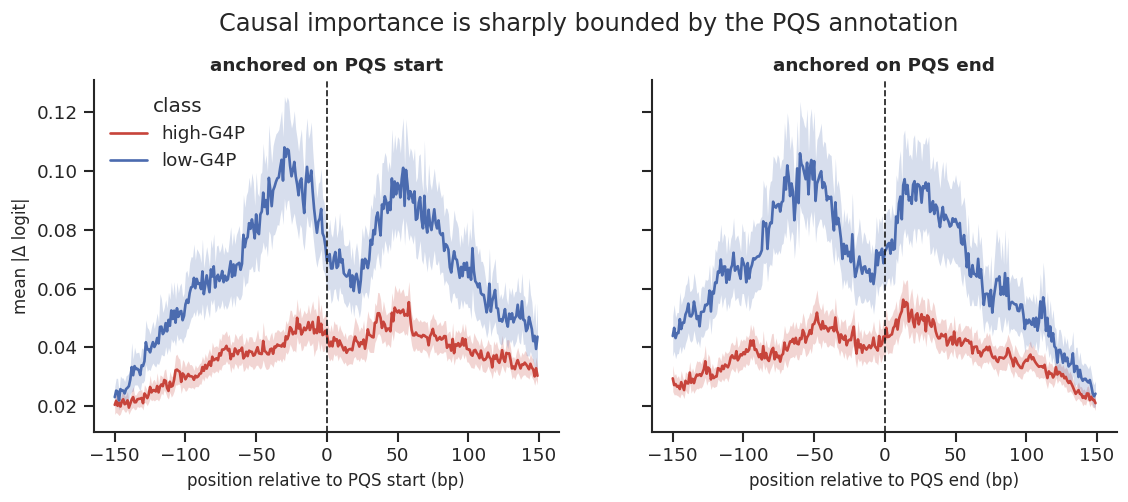

In [18]:
FL = 150   # flank to show on each side

def align_profile(imp, indices, anchor="start"):
    prof = np.full((len(indices), 2*FL), np.nan)
    for r, i in enumerate(indices):
        a = D1["pqs_start"][i] if anchor == "start" else D1["pqs_end"][i]
        lo, hi = a - FL, a + FL
        s, e = max(0, lo), min(L, hi)
        if e <= s: continue
        prof[r, (s-lo):(e-lo)] = imp[r, s:e]
    return prof

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
x = np.arange(-FL, FL)
for ax, anc in zip(axes, ["start", "end"]):
    for imp, idx, lab, col in [(imp_pos, idx_pos, "high-G4P", POS_C),
                               (imp_neg, idx_neg, "low-G4P",  NEG_C)]:
        P = align_profile(imp, idx, anc)
        m = np.nanmean(P, 0)
        se = np.nanstd(P, 0) / np.sqrt(np.sum(~np.isnan(P), 0))
        ax.plot(x, m, color=col, lw=1.6, label=lab)
        ax.fill_between(x, m-1.96*se, m+1.96*se, color=col, alpha=.22, lw=0)
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_xlabel(f"position relative to PQS {anc} (bp)")
    ax.set_title(f"anchored on PQS {anc}")
axes[0].set_ylabel("mean |Δ logit|"); axes[0].legend(title="class")
fig.suptitle("Causal importance is sharply bounded by the PQS annotation", y=1.03)
save(fig, "fig1b_pqs_aligned_profile"); plt.show()

### 2.3 Which bases, and in which direction?

Mean |Δ| hides sign. Now we separate **disruption** (mutating away from the reference
lowers the score) from **creation** (a substitution *raises* it), broken down by
reference base and by substituted base. G-tract integrity predicts a strong asymmetry:
mutating G should hurt, and mutating *to* G inside the PQS should help.

In [19]:
def sign_table(delta, indices):
    """Long dataframe: ref base, alt base, region, Δlogit."""
    recs = []
    for r, i in enumerate(indices):
        oh   = D1["seqs"][i]; ref = oh.argmax(0)
        s, e = max(0, D1["pqs_start"][i]), min(L, D1["pqs_end"][i])
        reg  = np.where((np.arange(L) >= s) & (np.arange(L) < e), "inside PQS", "flank")
        for b in range(4):
            m = ref != b
            recs.append(pd.DataFrame({"ref": np.array(BASES)[ref[m]],
                                      "alt": BASES[b],
                                      "region": reg[m],
                                      "d": delta[r, b, m]}))
    return pd.concat(recs, ignore_index=True)

S_pos = sign_table(ism_pos, idx_pos)
# Save the aggregate, not the millions of raw rows.
(S_pos.groupby(["region", "ref", "alt"])["d"]
      .agg(["mean", "median", "std", "count"])
      .reset_index().to_csv(OUT / "ism_substitution_stats.csv", index=False))
S_pos.groupby(["region", "ref"])["d"].agg(["mean", "median", "count"]).round(4)

mean  median   count
region     ref                        
flank      A    0.0099  0.0030  145047
           C   -0.0090 -0.0038  282765
           G   -0.0102 -0.0040  303585
           T    0.0116  0.0034  141171
inside PQS A    0.0202  0.0071    3543
           C   -0.0169 -0.0098    6348
           G   -0.0273 -0.0155   14925
           T    0.0420  0.0236    2616

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig1c_substitution_matrix.png


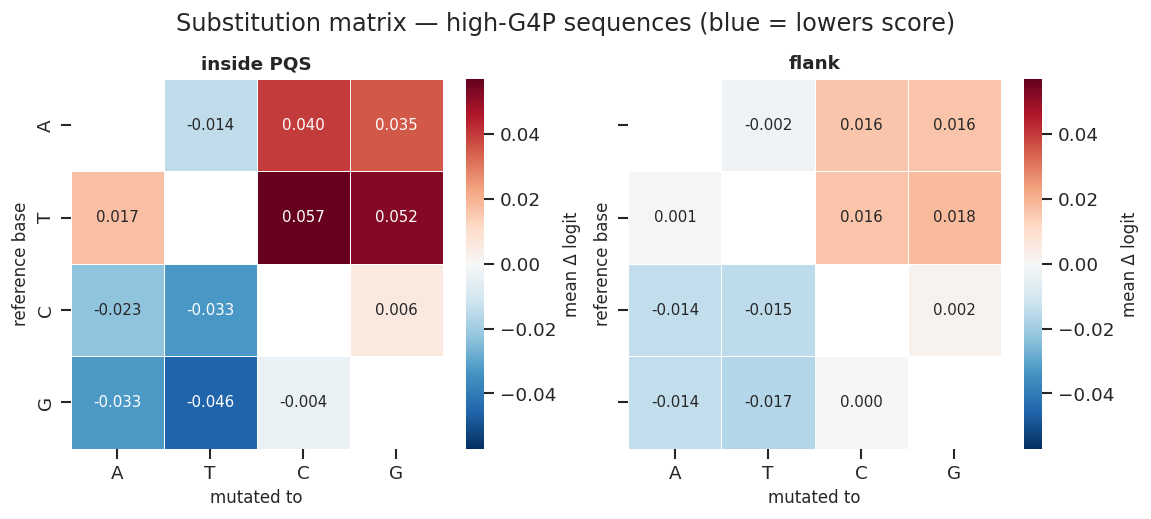

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
# Shared colour scale so the two panels are directly comparable.
_all = S_pos.groupby(["region", "ref", "alt"])["d"].mean()
V = np.nanmax(np.abs(_all.values))
for ax, reg in zip(axes, ["inside PQS", "flank"]):
    sub = S_pos[S_pos.region == reg]
    piv = sub.groupby(["ref", "alt"])["d"].mean().unstack().reindex(index=BASES, columns=BASES)
    np.fill_diagonal(piv.values, np.nan)      # ref==alt is not a mutation
    sns.heatmap(piv, cmap=DIVERGE, center=0, vmin=-V, vmax=V, ax=ax,
                annot=True, fmt=".3f", annot_kws={"size": 9},
                cbar_kws={"label": "mean Δ logit"}, linewidths=.5, linecolor="w")
    ax.set_title(reg); ax.set_xlabel("mutated to"); ax.set_ylabel("reference base")
fig.suptitle("Substitution matrix — high-G4P sequences (blue = lowers score)", y=1.02)
save(fig, "fig1c_substitution_matrix"); plt.show()

inside PQS:  mutating AWAY from G   mean Δ = -0.0273  (n=14,925)
             mutating away from A/T/C mean Δ = +0.0059  (n=12,507)
             Mann-Whitney p = 0.00e+00
             mutating TO G           mean Δ = +0.0237  (n=4,169)
saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig1d_g_directionality.png


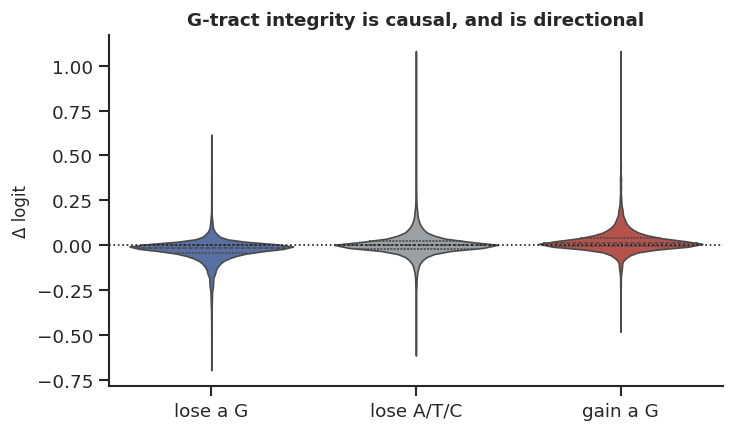

In [21]:
# Directional summary: does losing a G hurt more than losing anything else?
sub = S_pos[S_pos.region == "inside PQS"]
loseG = sub[sub.ref == "G"]["d"]
loseO = sub[sub.ref != "G"]["d"]
gainG = sub[(sub.alt == "G") & (sub.ref != "G")]["d"]
u = stats.mannwhitneyu(loseG, loseO)
print(f"inside PQS:  mutating AWAY from G   mean Δ = {loseG.mean():+.4f}  (n={len(loseG):,})")
print(f"             mutating away from A/T/C mean Δ = {loseO.mean():+.4f}  (n={len(loseO):,})")
print(f"             Mann-Whitney p = {u.pvalue:.2e}")
print(f"             mutating TO G           mean Δ = {gainG.mean():+.4f}  (n={len(gainG):,})")

fig, ax = plt.subplots(figsize=(6.6, 3.8))
plot_df = pd.concat([
    pd.DataFrame({"d": loseG, "what": "lose a G"}),
    pd.DataFrame({"d": loseO, "what": "lose A/T/C"}),
    pd.DataFrame({"d": gainG, "what": "gain a G"}),
])
sns.violinplot(data=plot_df, x="what", y="d", ax=ax, inner="quartile", cut=0,
               hue="what", legend=False,
               palette={"lose a G": NEG_C, "lose A/T/C": NEU_C, "gain a G": POS_C},
               linewidth=1)
ax.axhline(0, color="k", lw=1, ls=":")
ax.set_ylabel("Δ logit"); ax.set_xlabel("")
ax.set_title("G-tract integrity is causal, and is directional")
save(fig, "fig1d_g_directionality"); plt.show()

### 2.4 The ISM logo — what the grammar looks like

A sequence logo of the *mean* PQS-aligned ISM, where letter height is the score **lost**
when that base is removed. This is the model's own reading of a G4 motif, learned without
ever being told the regex.

**Length matching matters.** PQS length varies (median ≈26 bp, IQR ≈22–33), so averaging a
wide window across all sequences would blur the motif — positions past the PQS end would
mix real motif in short examples with flank in long ones. We therefore restrict the logo to
PQSs in a narrow length band and only plot out to that band's length.

logo uses 104/300 positives with PQS length 24-31 bp (median 26)
saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig1e_ism_logo.png


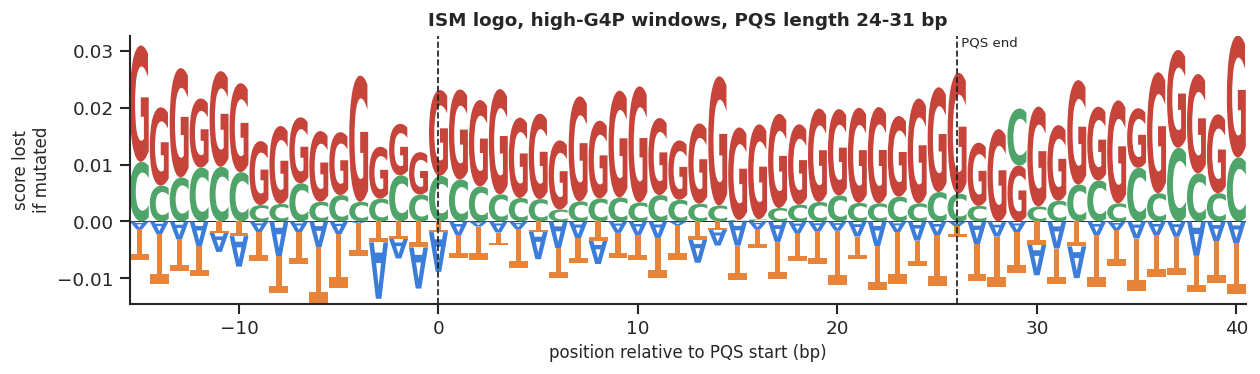

In [22]:
import logomaker

def ism_logo_matrix(deltas, indices, rows, anchor="start", span=(-15, 45)):
    """rows = positions within `indices` to include (already length-matched)."""
    lo, hi = span
    W = hi - lo
    acc = np.zeros((W, 4)); cnt = np.zeros((W, 1))
    for r in rows:
        i = indices[r]
        a = D1["pqs_start"][i] if anchor == "start" else D1["pqs_end"][i]
        ref = D1["seqs"][i].argmax(0)
        for k in range(W):
            p = a + lo + k
            if not (0 <= p < L): continue
            # height of the REFERENCE base = how much score is lost by mutating it away
            acc[k, ref[p]] += -deltas[r, :, p].sum() / 3.0
            cnt[k] += 1
    return pd.DataFrame(acc / np.maximum(cnt, 1), columns=BASES, index=np.arange(lo, hi))

# Length-matched subset: PQSs within the central band of the length distribution
plen = (D1["pqs_end"] - D1["pqs_start"])[idx_pos]
lo_l, hi_l = np.percentile(plen, [35, 65])
rows = np.where((plen >= lo_l) & (plen <= hi_l))[0]
band = int(np.median(plen[rows]))
print(f"logo uses {len(rows)}/{len(idx_pos)} positives with PQS length "
      f"{lo_l:.0f}-{hi_l:.0f} bp (median {band})")

Mlogo = ism_logo_matrix(ism_pos, idx_pos, rows, span=(-15, band + 15))
fig, ax = plt.subplots(figsize=(12, 2.9))
logomaker.Logo(Mlogo, ax=ax, color_scheme={b: BASE_COLORS[b] for b in BASES},
               shade_below=.0, fade_below=.0)
ax.axvline(0, color="k", ls="--", lw=1)
ax.axvline(band, color="k", ls="--", lw=1)
ax.text(band, ax.get_ylim()[1], " PQS end", fontsize=8, va="top")
ax.set_xlabel("position relative to PQS start (bp)")
ax.set_ylabel("score lost\nif mutated")
ax.set_title(f"ISM logo, high-G4P windows, PQS length {lo_l:.0f}-{hi_l:.0f} bp")
save(fig, "fig1e_ism_logo"); plt.show()

### 2.5 Positives vs negatives — is the *grammar* different, or just the amount?

Key discrimination. If negatives show the same-shaped but weaker profile, the model reads
one continuous "G4 strength" axis. If the profile is shaped differently, the classes are
being read by different rules.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig1f_pos_vs_neg.png


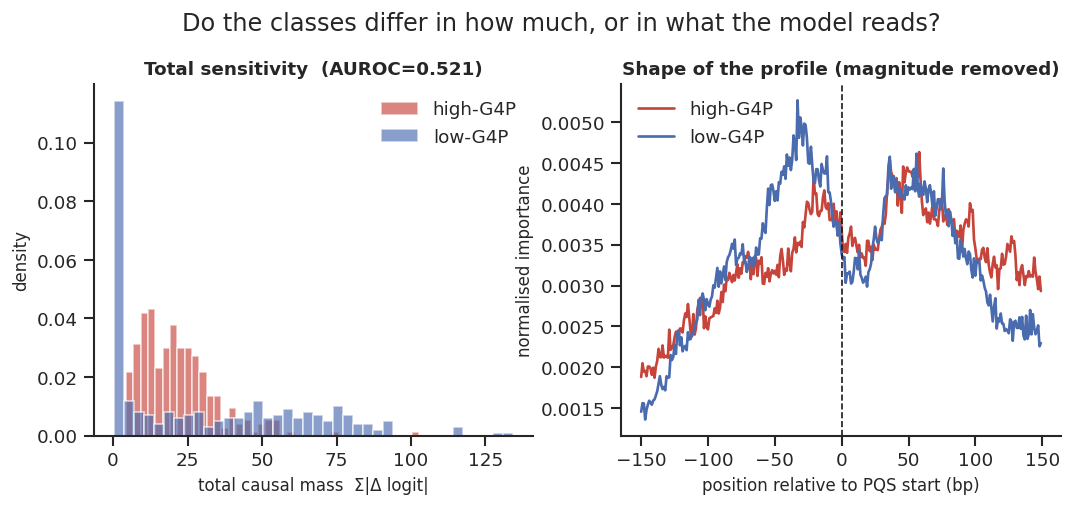

In [23]:
tot_pos = np.abs(ism_pos).sum((1, 2)) / 3
tot_neg = np.abs(ism_neg).sum((1, 2)) / 3

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.8))
ax = axes[0]
ax.hist(tot_pos, bins=40, alpha=.65, color=POS_C, label="high-G4P", density=True)
ax.hist(tot_neg, bins=40, alpha=.65, color=NEG_C, label="low-G4P", density=True)
ax.set_xlabel("total causal mass  Σ|Δ logit|"); ax.set_ylabel("density"); ax.legend()
ax.set_title(f"Total sensitivity  (AUROC={roc_auc_score(np.r_[np.ones(len(tot_pos)), np.zeros(len(tot_neg))], np.r_[tot_pos, tot_neg]):.3f})")

# shape comparison: normalise each profile to sum 1, then compare
ax = axes[1]
for P, lab, col in [(align_profile(imp_pos, idx_pos), "high-G4P", POS_C),
                    (align_profile(imp_neg, idx_neg), "low-G4P",  NEG_C)]:
    Pn = P / np.nansum(P, 1, keepdims=True)
    m  = np.nanmean(Pn, 0)
    ax.plot(np.arange(-FL, FL), m, color=col, lw=1.6, label=lab)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("position relative to PQS start (bp)")
ax.set_ylabel("normalised importance"); ax.legend()
ax.set_title("Shape of the profile (magnitude removed)")
fig.suptitle("Do the classes differ in how much, or in what the model reads?", y=1.04)
save(fig, "fig1f_pos_vs_neg"); plt.show()

**Interpretation guide.**
- Left panel separated, right panel overlapping → one continuous strength axis; the model
  scores *degree* of G4-ness, and the binary label is a cut on that axis.
- Right panel differing in shape → genuinely different grammar between the classes.

Read the actual output before writing either conclusion.

---
## 3. Synthetic sequence perturbation

> **What explicit rules are *sufficient* to change the prediction?**

ISM tells us what matters in sequences that already exist; it cannot separate correlated
variables — in the genome, tract length, loop length and GC content all covary. Here we
**construct** sequences, varying one factor at a time against a fixed set of scaffolds, so
every reported effect is a controlled causal contrast.

All conditions share the **same** scaffolds and are compared against the **same** baseline
(`base`), making every contrast paired.

### ⚠️ Choice of background matters enormously — measured, not assumed

The obvious design (implant a motif into a random 41 %-GC background) **fails**, and it
fails silently. A random background is far outside the distribution of real PQS windows:
it scores ≈ −8.3 logits, where the sigmoid is saturated and the gradient is ~0. Implanting
a canonical G4 there moves the score by ~0.05 logits, and the resulting "dose–response"
curves are noise — in a pilot they even ran *backwards* (long loops scoring higher than
short ones).

The fix is an **in-distribution scaffold**: take real genomic PQS windows and shuffle only
the central 120 bp, destroying the native motif while preserving genomic flanks and
composition. That scaffold sits at ≈ −0.7 logits, in the model's responsive range, and
effect sizes become 10–50× larger with the correct sign.

| background | mean logit | Δ for G3N3×4 | loop 3 → 12 |
|---|---|---|---|
| random 41 % GC | −8.3 | +0.05 | +0.05 → **+0.12** (backwards) |
| centre-shuffled real window | −0.7 | see below | −0.09 → **−2.51** (correct) |

Cell 3.0 re-measures this so the choice is justified by output, not assertion.

In [24]:
RNG = np.random.default_rng(SEED)

def to_onehot(seq):
    oh = np.zeros((4, len(seq)), np.int8)
    for i, b in enumerate(seq):
        j = B2I.get(b)
        if j is not None: oh[j, i] = 1
    return oh

def onehot_to_str(oh):
    s = np.array(BASES)[oh.argmax(0)]
    s[oh.sum(0) == 0] = "N"          # unmapped bases (N in genome) stay N
    return "".join(s)

def random_bg(length, gc=0.41, rng=RNG):
    """Naive background — kept only to demonstrate why it is the wrong control."""
    p = [(1-gc)/2, (1-gc)/2, gc/2, gc/2]        # A, T, C, G
    return "".join(rng.choice(BASES, size=length, p=p))

CORE_LO, CORE_HI = 440, 560      # central 120 bp: the implantation core

def make_scaffolds(n, rng=RNG, pool=20000):
    """Real PQS windows with the central 120 bp shuffled → in-distribution, motif-free."""
    cand = rng.choice(pool, n, replace=False)
    out = []
    for i in cand:
        s = onehot_to_str(np.asarray(D1["seqs"][i]))
        core = list(s[CORE_LO:CORE_HI]); rng.shuffle(core)
        out.append(s[:CORE_LO] + "".join(core) + s[CORE_HI:])
    return out

def score_seqs(seqs, batch=1024):
    return predict_logits(np.stack([to_onehot(s) for s in seqs]), batch=batch)

def make_motif(tract=3, loop=3, n_tract=4, loop_seq=None, rng=RNG):
    parts = []
    for k in range(n_tract):
        parts.append("G" * tract)
        if k < n_tract - 1:
            parts.append(loop_seq if loop_seq is not None
                         else "".join(rng.choice(BASES, size=loop)))
    return "".join(parts)

def implant(scaf, motif):
    """Centre the motif in the shuffled core; window length is invariant."""
    st = CORE_LO + (CORE_HI - CORE_LO - len(motif)) // 2
    assert 0 <= st and st + len(motif) <= L, "motif does not fit in the core"
    out = scaf[:st] + motif + scaf[st+len(motif):]
    assert len(out) == L
    return out

def build_g4(tract=3, loop=3, n_tract=4, loop_seq=None, bg=None, rng=RNG):
    """Convenience wrapper: motif implanted into scaffold `bg`."""
    m = make_motif(tract, loop, n_tract, loop_seq, rng)
    return implant(bg, m), CORE_LO, len(m)

#### 3.0 Justify the scaffold empirically

In [25]:
_n = 40
_scaf = make_scaffolds(_n)
_rand = [random_bg(L) for _ in range(_n)]
_real = [onehot_to_str(np.asarray(D1["seqs"][i])) for i in RNG.choice(20000, _n, replace=False)]

_bench = []
for nm, bg in [("real PQS windows", _real), ("centre-shuffled (scaffold)", _scaf),
               ("random 41% GC", _rand)]:
    b = score_seqs(bg)
    d3 = score_seqs([implant(s, make_motif(3, 3, 4, "ATA")) for s in bg]) - b
    d12 = score_seqs([implant(s, make_motif(3, 12, 4, "ATATATATATAT"[:12])) for s in bg]) - b
    _bench.append(dict(background=nm, mean_logit=b.mean(),
                       d_loop3=d3.mean(), d_loop12=d12.mean()))
BENCH = pd.DataFrame(_bench)
print(BENCH.round(3).to_string(index=False))
print("\nUsing the centre-shuffled scaffold: in-distribution and responsive.")
BENCH.to_csv(OUT / "synth_background_choice.csv", index=False)

                background  mean_logit  d_loop3  d_loop12
          real PQS windows      -4.025   -0.296    -2.536
centre-shuffled (scaffold)      -3.253    0.015    -2.408
             random 41% GC      -8.327    0.005    -0.013

Using the centre-shuffled scaffold: in-distribution and responsive.


### 3.1 G-tract length and number of tracts

Canonical G4 biology: four tracts of ≥3 G. Does the model reproduce the ≥3 threshold and
the 4-tract requirement it was never told about?

Loops are fixed to `ATA` here so that tract length is the *only* thing varying — a random
loop would change composition alongside it.

scaffold baseline: -2.019 ± 4.166
saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2a_tract_grammar.png


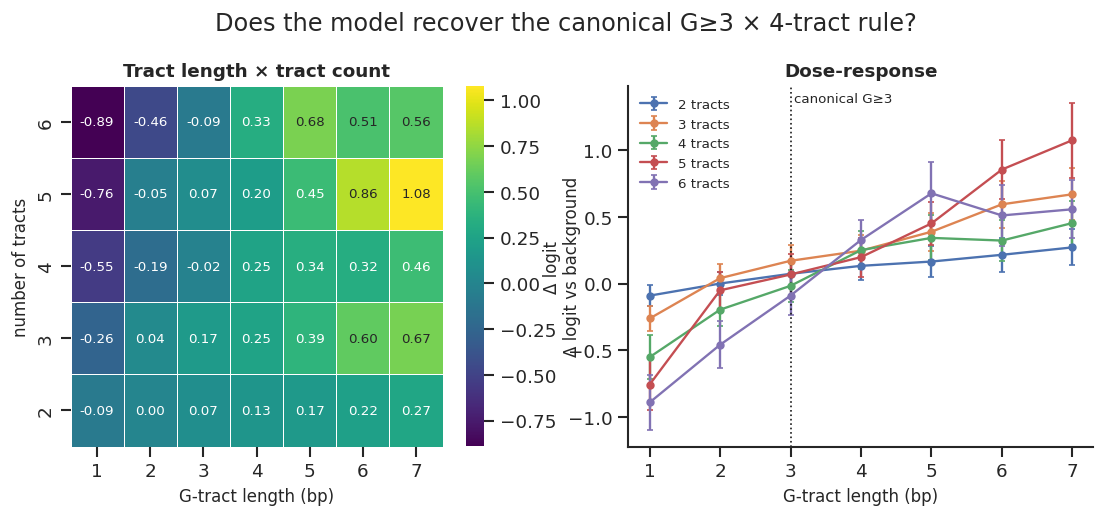

In [26]:
N_REP = 60   # independent scaffolds, held FIXED across all conditions (paired design)
bgs   = make_scaffolds(N_REP)
base  = score_seqs(bgs)          # computed once; every Δ below is paired against it
print(f"scaffold baseline: {base.mean():+.3f} ± {base.std():.3f}")

recs = []
for tract in range(1, 8):
    for ntr in range(2, 7):
        s = score_seqs([implant(b, make_motif(tract, 3, ntr, "ATA")) for b in bgs])
        for a, b_ in zip(s, base):
            recs.append(dict(tract=tract, n_tract=ntr, logit=a, delta=a-b_))
G = pd.DataFrame(recs)
G.to_csv(OUT / "synth_tract.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
piv = G.groupby(["n_tract", "tract"])["delta"].mean().unstack()
sns.heatmap(piv, cmap="viridis", ax=axes[0], annot=True, fmt=".2f", annot_kws={"size": 8},
            cbar_kws={"label": "Δ logit vs background"}, linewidths=.5, linecolor="w")
axes[0].set_xlabel("G-tract length (bp)"); axes[0].set_ylabel("number of tracts")
axes[0].set_title("Tract length × tract count")
axes[0].invert_yaxis()

for ntr, sub in G.groupby("n_tract"):
    m = sub.groupby("tract")["delta"].mean(); e = sub.groupby("tract")["delta"].sem()
    axes[1].errorbar(m.index, m.values, yerr=1.96*e.values, marker="o", ms=4,
                     capsize=2, lw=1.4, label=f"{ntr} tracts")
axes[1].axvline(3, color="k", ls=":", lw=1)
axes[1].text(3.05, axes[1].get_ylim()[1]*.92, "canonical G≥3", fontsize=8)
axes[1].set_xlabel("G-tract length (bp)"); axes[1].set_ylabel("Δ logit")
axes[1].legend(fontsize=8); axes[1].set_title("Dose-response")
fig.suptitle("Does the model recover the canonical G≥3 × 4-tract rule?", y=1.04)
save(fig, "fig2a_tract_grammar"); plt.show()

### 3.2 Loop length

Biophysically, short loops (1–3 nt) give the most stable G4s and stability falls as loops
lengthen. A model that learned real G4 grammar should show a decreasing response.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2b_loop_length.png


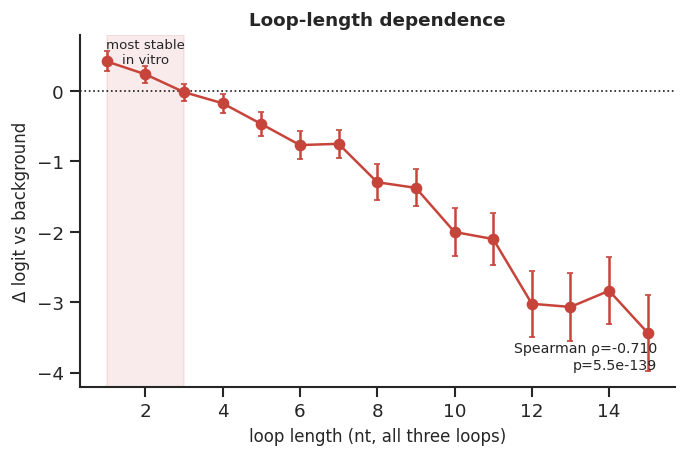

In [27]:
recs = []
for loop in range(1, 16):
    # loop sequence is a fixed AT repeat truncated to length → composition controlled
    ls = ("ATATATATATATATAT")[:loop]
    s = score_seqs([implant(b, make_motif(3, loop, 4, ls)) for b in bgs])
    for a, b_ in zip(s, base):
        recs.append(dict(loop=loop, delta=a-b_))
Lp = pd.DataFrame(recs); Lp.to_csv(OUT / "synth_loop_len.csv", index=False)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
m = Lp.groupby("loop")["delta"].mean(); e = Lp.groupby("loop")["delta"].sem()
ax.errorbar(m.index, m.values, yerr=1.96*e.values, marker="o", color=POS_C, capsize=2)
ax.axhline(0, color="k", ls=":", lw=1)
ax.axvspan(1, 3, color=POS_C, alpha=.10)
ax.text(2, ax.get_ylim()[1]*.95, "most stable\nin vitro", ha="center", fontsize=8, va="top")
ax.set_xlabel("loop length (nt, all three loops)"); ax.set_ylabel("Δ logit vs background")
ax.set_title("Loop-length dependence")
r = stats.spearmanr(Lp["loop"], Lp["delta"])
ax.text(.97, .05, f"Spearman ρ={r.correlation:.3f}\np={r.pvalue:.1e}", transform=ax.transAxes,
        ha="right", fontsize=8.5)
save(fig, "fig2b_loop_length"); plt.show()

### 3.3 Loop composition

With loop *length* fixed at 3, does the identity of the loop bases matter?

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2c_loop_composition.png


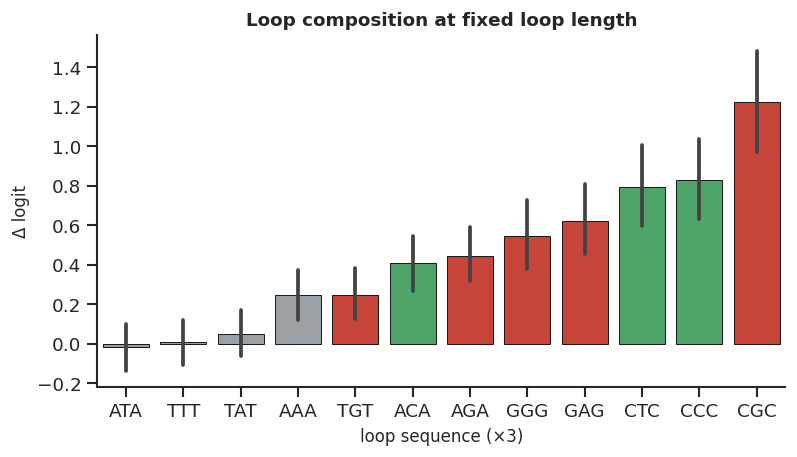

In [28]:
LOOPS = ["AAA","TTT","CCC","GGG","ATA","TAT","CTC","ACA","GAG","CGC","TGT","AGA"]
recs = []
for ls in LOOPS:
    s = score_seqs([implant(b, make_motif(3, 3, 4, ls)) for b in bgs])
    for a, b_ in zip(s, base):
        recs.append(dict(loop_seq=ls, delta=a-b_))
LC = pd.DataFrame(recs); LC.to_csv(OUT / "synth_loop_comp.csv", index=False)

order = LC.groupby("loop_seq")["delta"].mean().sort_values().index
fig, ax = plt.subplots(figsize=(7.4, 3.8))
sns.barplot(data=LC, x="loop_seq", y="delta", order=order, ax=ax,
            errorbar=("ci", 95), color=NEU_C, edgecolor="k", linewidth=.6)
for i, ls in enumerate(order):
    if "G" in ls:  ax.patches[i].set_facecolor(BASE_COLORS["G"])
    elif "C" in ls: ax.patches[i].set_facecolor(BASE_COLORS["C"])
ax.set_xlabel("loop sequence (×3)"); ax.set_ylabel("Δ logit")
ax.set_title("Loop composition at fixed loop length")
save(fig, "fig2c_loop_composition"); plt.show()

### 3.4 G-tract interruption

Replace one G inside one tract. Where in the tract does the interruption hurt most, and
which base is least damaging?

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2d_interruption.png


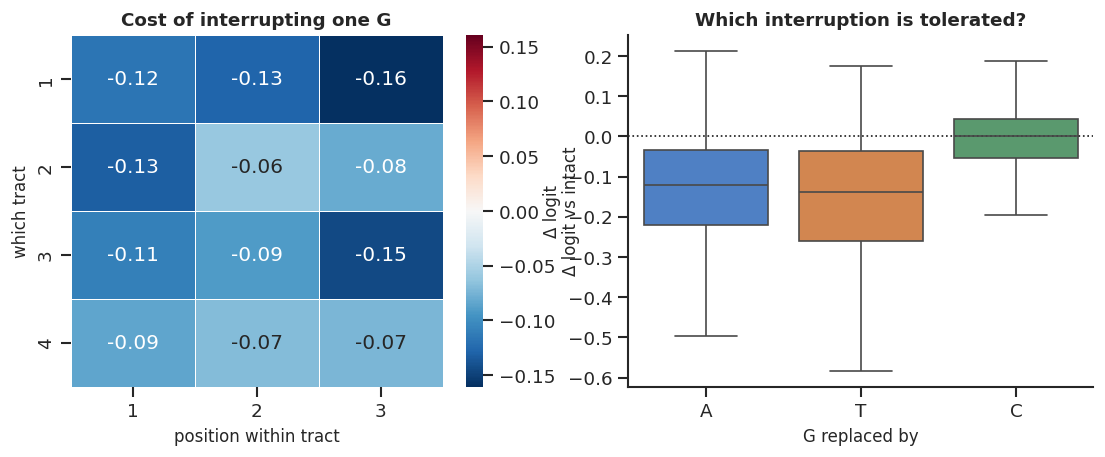

In [29]:
# Reference = the intact G3/ATA/x4 motif in the same scaffolds (paired, computed once)
intact_score = score_seqs([implant(b, make_motif(3, 3, 4, "ATA")) for b in bgs])

recs = []
for tract_i in range(4):
    for pos_i in range(3):
        for sb in ["A","T","C"]:
            parts = []
            for k in range(4):
                t = list("GGG")
                if k == tract_i: t[pos_i] = sb
                parts.append("".join(t))
            motif = "ATA".join(parts)
            d = score_seqs([implant(b, motif) for b in bgs]) - intact_score
            for v in d:
                recs.append(dict(tract=tract_i+1, pos=pos_i+1, sub=sb, delta=v))
IT = pd.DataFrame(recs); IT.to_csv(OUT / "synth_interrupt.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
piv = IT.groupby(["tract","pos"])["delta"].mean().unstack()
v = np.abs(piv.values).max()
sns.heatmap(piv, cmap=DIVERGE, center=0, vmin=-v, vmax=v, ax=axes[0], annot=True, fmt=".2f",
            cbar_kws={"label":"Δ logit vs intact"}, linewidths=.5, linecolor="w")
axes[0].set_xlabel("position within tract"); axes[0].set_ylabel("which tract")
axes[0].set_title("Cost of interrupting one G")

sns.boxplot(data=IT, x="sub", y="delta", ax=axes[1], hue="sub", legend=False,
            palette={b: BASE_COLORS[b] for b in ["A","T","C"]},
            showfliers=False, linewidth=1)
axes[1].axhline(0, color="k", ls=":", lw=1)
axes[1].set_xlabel("G replaced by"); axes[1].set_ylabel("Δ logit")
axes[1].set_title("Which interruption is tolerated?")
save(fig, "fig2d_interruption"); plt.show()

### 3.5 Spare tracts — is a 5th G-run protective?

A real biological signature: an extra G-run lets the G4 re-form after an interruption.
This tests **higher-order structure**, not just local composition. We compare an
interrupted 4-tract G4 with and without a spare tract available.

interrupted, no spare      : -0.139
interrupted, + GGG spare   : -0.121   rescue = +0.018   (paired t p=7.48e-01)
interrupted, + AAA control : -0.497   'rescue' = -0.358

G-SPECIFIC RESCUE = +0.376   <- this is the number that matters
saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2e_spare_tract_rescue.png


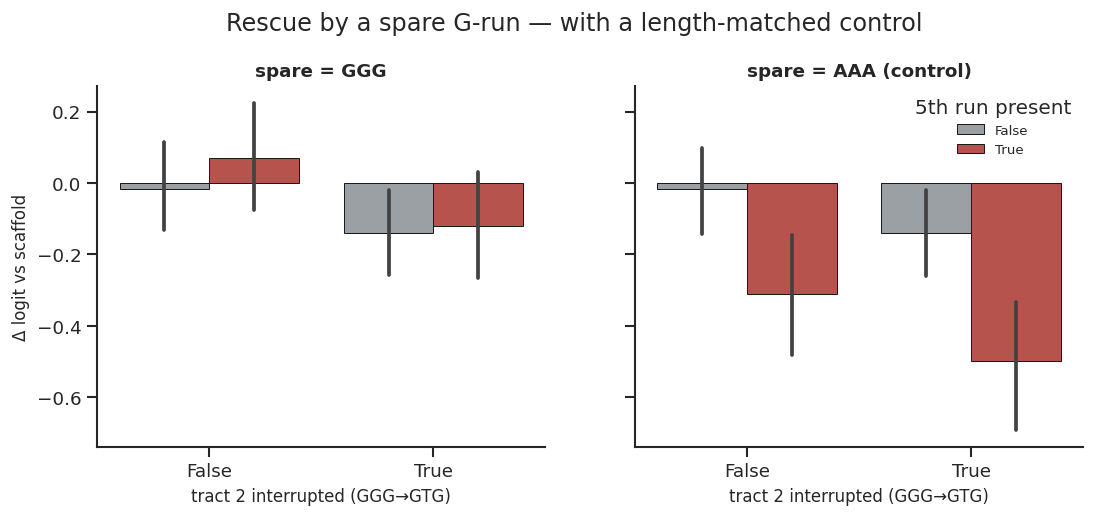

In [30]:
def spare_motif(interrupted, spare, loop="ATA"):
    """4 tracts, optionally with tract-2 interrupted and/or a spare 5th run.

    Length is NOT matched across the spare/no-spare arms (the spare run adds 6 bp);
    the `AAA`-run control below absorbs that, isolating the G-specific effect.
    """
    tracts = ["GGG"] * 4
    if interrupted: tracts[1] = "GTG"
    if spare:       tracts.append("GGG")
    return loop.join(tracts)

def filler_motif(interrupted, spare, loop="ATA"):
    """Length-matched control: the 5th run is AAA, which cannot serve as a G-tract."""
    tracts = ["GGG"] * 4
    if interrupted: tracts[1] = "GTG"
    if spare:       tracts.append("AAA")
    return loop.join(tracts)

recs = []
for interrupted in [False, True]:
    for spare in [False, True]:
        s  = score_seqs([implant(b, spare_motif(interrupted, spare))  for b in bgs]) - base
        sf = score_seqs([implant(b, filler_motif(interrupted, spare)) for b in bgs]) - base
        for v, vf in zip(s, sf):
            recs.append(dict(interrupted=interrupted, spare=spare,
                             delta=v, delta_filler=vf))
SP = pd.DataFrame(recs); SP.to_csv(OUT / "synth_spare_tract.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.9), sharey=True)
long = SP.melt(id_vars=["interrupted", "spare"],
               value_vars=["delta", "delta_filler"],
               var_name="arm", value_name="d")
long["arm"] = long["arm"].map({"delta": "spare = GGG", "delta_filler": "spare = AAA (control)"})
for ax, arm in zip(axes, ["spare = GGG", "spare = AAA (control)"]):
    sns.barplot(data=long[long.arm == arm], x="interrupted", y="d", hue="spare", ax=ax,
                errorbar=("ci",95), palette=[NEU_C, POS_C], edgecolor="k", linewidth=.6)
    ax.set_xlabel("tract 2 interrupted (GGG→GTG)"); ax.set_title(arm)
    ax.get_legend().remove()
axes[0].set_ylabel("Δ logit vs scaffold")
axes[1].legend(title="5th run present", fontsize=8)
fig.suptitle("Rescue by a spare G-run — with a length-matched control", y=1.04)

a  = SP[(SP.interrupted) & (~SP.spare)]["delta"]
b_ = SP[(SP.interrupted) & ( SP.spare)]["delta"]
af = SP[(SP.interrupted) & (~SP.spare)]["delta_filler"]
bf = SP[(SP.interrupted) & ( SP.spare)]["delta_filler"]
rescue_G, rescue_A = b_.mean() - a.mean(), bf.mean() - af.mean()
print(f"interrupted, no spare      : {a.mean():+.3f}")
print(f"interrupted, + GGG spare   : {b_.mean():+.3f}   rescue = {rescue_G:+.3f}"
      f"   (paired t p={stats.ttest_rel(a.values, b_.values).pvalue:.2e})")
print(f"interrupted, + AAA control : {bf.mean():+.3f}   'rescue' = {rescue_A:+.3f}")
print(f"\nG-SPECIFIC RESCUE = {rescue_G - rescue_A:+.3f}"
      "   <- this is the number that matters")
save(fig, "fig2e_spare_tract_rescue"); plt.show()

### 3.6 C-rich competitor and flanking context

Two context effects at once: a competing C-run (which would base-pair with the G-tracts
and suppress G4 formation), and the GC content of the flanks. Both are *outside* the PQS,
so a positive result here is direct evidence the model integrates broader context.

flank GC range in real windows: 0.27–0.85 (median 0.57)
saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2f_context.png


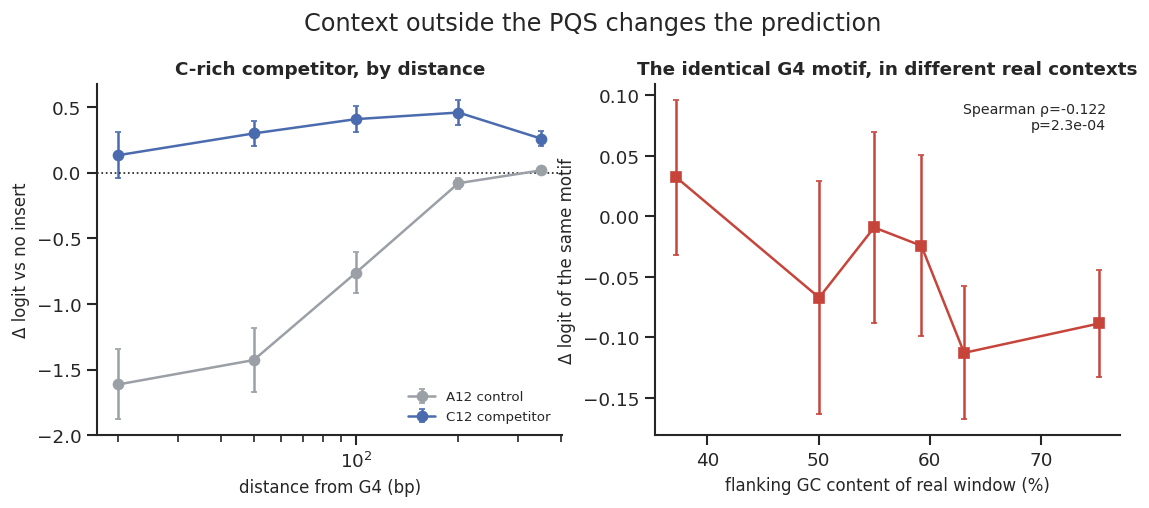

In [31]:
# ── (a) C-rich competitor at increasing distance ─────────────────────────────
G4_MOTIF = make_motif(3, 3, 4, "ATA")
MOT_ST   = CORE_LO + (CORE_HI - CORE_LO - len(G4_MOTIF)) // 2
ref_score = score_seqs([implant(b, G4_MOTIF) for b in bgs])   # same motif, no insert

recs = []
for dist in [20, 50, 100, 200, 350]:
    for comp, lab in [("C"*12, "C12 competitor"), ("A"*12, "A12 control")]:
        p = MOT_ST + len(G4_MOTIF) + dist
        if p + len(comp) > L: continue
        seqs = []
        for b in bgs:
            s = implant(b, G4_MOTIF)
            seqs.append(s[:p] + comp + s[p+len(comp):])
        for v in score_seqs(seqs) - ref_score:
            recs.append(dict(dist=dist, kind=lab, delta=v))
CC = pd.DataFrame(recs); CC.to_csv(OUT / "synth_competitor.csv", index=False)

# ── (b) Flanking GC: use REAL windows, stratified by their own flank GC ───────
# Varying flanks synthetically would leave the data distribution (see §3.0), so we
# instead bin real scaffolds by measured flank GC and implant the identical motif.
_pool  = RNG.choice(20000, 900, replace=False)
_scafs, _gcs = [], []
for i in _pool:
    s = onehot_to_str(np.asarray(D1["seqs"][i]))
    core = list(s[CORE_LO:CORE_HI]); RNG.shuffle(core)
    sc = s[:CORE_LO] + "".join(core) + s[CORE_HI:]
    flank = sc[:CORE_LO] + sc[CORE_HI:]
    _scafs.append(sc)
    _gcs.append((flank.count("G") + flank.count("C")) / len(flank))
_gcs = np.array(_gcs)

b_all = score_seqs(_scafs)
m_all = score_seqs([implant(s, G4_MOTIF) for s in _scafs])
qs    = np.quantile(_gcs, np.linspace(0, 1, 7))
GCd = pd.DataFrame(dict(gc=_gcs, delta=m_all - b_all, motif_logit=m_all, bg_logit=b_all))
GCd["gc_bin"] = pd.cut(GCd["gc"], bins=np.unique(qs), include_lowest=True)
GCd.to_csv(OUT / "synth_flank_gc.csv", index=False)
print(f"flank GC range in real windows: {_gcs.min():.2f}–{_gcs.max():.2f} "
      f"(median {np.median(_gcs):.2f})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for kind, sub in CC.groupby("kind"):
    m = sub.groupby("dist")["delta"].mean(); e = sub.groupby("dist")["delta"].sem()
    axes[0].errorbar(m.index, m.values, yerr=1.96*e.values, marker="o", capsize=2,
                     label=kind, color=NEG_C if "C12" in kind else NEU_C)
axes[0].axhline(0, color="k", ls=":", lw=1); axes[0].set_xscale("log")
axes[0].set_xlabel("distance from G4 (bp)"); axes[0].set_ylabel("Δ logit vs no insert")
axes[0].legend(fontsize=8); axes[0].set_title("C-rich competitor, by distance")

gb = GCd.groupby("gc_bin", observed=True)
m, e = gb["delta"].mean(), gb["delta"].sem()
xc = np.array([iv.mid for iv in m.index]) * 100
axes[1].errorbar(xc, m.values, yerr=1.96*e.values, marker="s", color=POS_C, capsize=2)
rho = stats.spearmanr(GCd["gc"], GCd["delta"])
axes[1].text(.97, .95, f"Spearman ρ={rho.correlation:+.3f}\np={rho.pvalue:.1e}",
             transform=axes[1].transAxes, ha="right", va="top", fontsize=8.5)
axes[1].set_xlabel("flanking GC content of real window (%)")
axes[1].set_ylabel("Δ logit of the same motif")
axes[1].set_title("The identical G4 motif, in different real contexts")
fig.suptitle("Context outside the PQS changes the prediction", y=1.04)
save(fig, "fig2f_context"); plt.show()

> **Reading the competitor panel carefully.** The C12-vs-A12 contrast confounds two things:
> C12 adds a C-run (a putative G4 *competitor*) but A12 adds an A-run, and the two also
> differ in GC content, which the model is independently sensitive to. A large positive
> C12−A12 difference is therefore at least as consistent with "the model likes local GC"
> as with "the model models strand competition". Treat the *distance dependence* — whether
> the effect decays with separation — as the informative part, not the raw sign.

### 3.7 Grammar summary

One figure collecting the effect sizes, so the learned rule can be stated as a sentence.

Effects are reported in logits. For scale: the scaffold baseline has a large spread
(≈±4 logits) because real windows differ a lot, which is why every contrast is **paired**
on the same scaffolds — the paired Δ is far more precise than that spread suggests.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig2g_grammar_summary.png


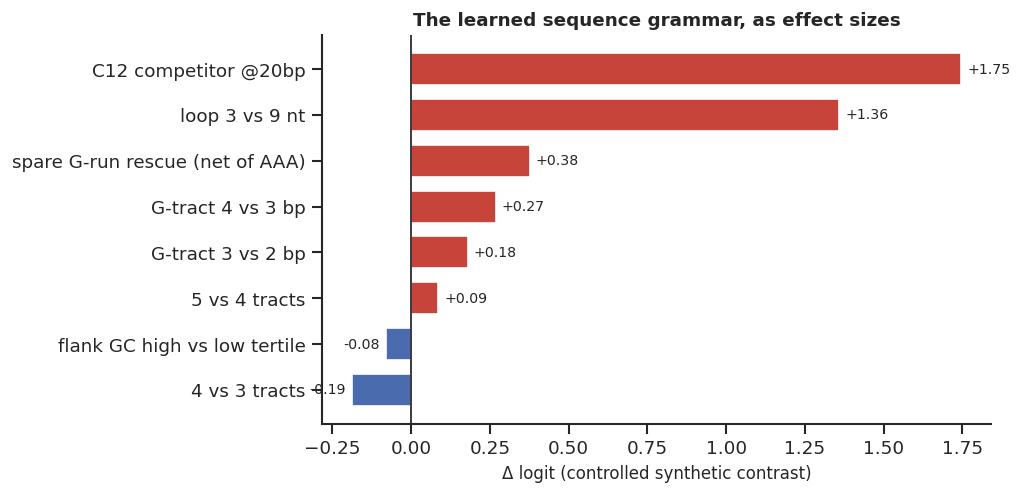

,contrast,Δ logit,Cohen d
2,4 vs 3 tracts,-0.187958,-0.403597
5,flank GC high vs low tertile,-0.081518,-0.189428
3,5 vs 4 tracts,0.085041,0.158439
0,G-tract 3 vs 2 bp,0.178869,0.373537
1,G-tract 4 vs 3 bp,0.267965,0.518283
6,spare G-run rescue (net of AAA),0.375918,NaN
4,loop 3 vs 9 nt,1.359411,1.677329
7,C12 competitor @20bp,1.745324,NaN


In [32]:
def eff(df, col, hi, lo):
    a = df[df[col] == hi]["delta"]; b = df[df[col] == lo]["delta"]
    d = a.mean() - b.mean()
    sd = np.sqrt((a.var() + b.var()) / 2)
    return d, d / max(sd, 1e-9)

summ = []
g4 = G[G.n_tract == 4]
summ.append(("G-tract 3 vs 2 bp",      *eff(g4, "tract", 3, 2)))
summ.append(("G-tract 4 vs 3 bp",      *eff(g4, "tract", 4, 3)))
gt3 = G[G.tract == 3]
summ.append(("4 vs 3 tracts",          *eff(gt3, "n_tract", 4, 3)))
summ.append(("5 vs 4 tracts",          *eff(gt3, "n_tract", 5, 4)))
summ.append(("loop 3 vs 9 nt",         *eff(Lp, "loop", 3, 9)))

# flank GC: top vs bottom tertile of REAL windows
lo_q, hi_q = GCd["gc"].quantile([1/3, 2/3])
_hi = GCd[GCd.gc >= hi_q]["delta"]; _lo = GCd[GCd.gc <= lo_q]["delta"]
summ.append(("flank GC high vs low tertile", _hi.mean() - _lo.mean(),
             (_hi.mean()-_lo.mean()) / max(np.sqrt((_hi.var()+_lo.var())/2), 1e-9)))

# spare-tract rescue, net of the length-matched AAA control
sp_i = SP[SP.interrupted]
_rg = sp_i[sp_i.spare]["delta"].mean()        - sp_i[~sp_i.spare]["delta"].mean()
_ra = sp_i[sp_i.spare]["delta_filler"].mean() - sp_i[~sp_i.spare]["delta_filler"].mean()
summ.append(("spare G-run rescue (net of AAA)", _rg - _ra, np.nan))

_d = CC["dist"].min()
cc = CC[CC.dist == _d]
summ.append((f"C12 competitor @{_d}bp",
             cc[cc.kind.str.startswith("C12")]["delta"].mean()
             - cc[cc.kind.str.startswith("A12")]["delta"].mean(), np.nan))

SUM = pd.DataFrame(summ, columns=["contrast", "Δ logit", "Cohen d"]).sort_values("Δ logit")
SUM.to_csv(OUT / "synth_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
cols = [POS_C if v > 0 else NEG_C for v in SUM["Δ logit"]]
ax.barh(SUM["contrast"], SUM["Δ logit"], color=cols, height=.7)
ax.axvline(0, color="k", lw=1)
for i, v in enumerate(SUM["Δ logit"]):
    ax.text(v + (.02 if v > 0 else -.02), i, f"{v:+.2f}",
            va="center", ha="left" if v > 0 else "right", fontsize=8.5)
ax.set_xlabel("Δ logit (controlled synthetic contrast)")
ax.set_title("The learned sequence grammar, as effect sizes")
save(fig, "fig2g_grammar_summary"); plt.show()
SUM

---
## 4. Layerwise representation probing

> **Where in the CNN→Transformer hierarchy is each property encoded?**

We extract the CNN token embeddings and the output of each of the 4 Transformer layers,
then probe each with a **linear** model for interpretable properties.

Two methodological commitments:
1. **Linear probes only.** A nonlinear probe can manufacture information that the rest of
   the network cannot use linearly; a linear probe measures *decodability*.
2. **Train/test split on sequences.** Probe scores are reported on held-out windows, so a
   high score cannot come from memorisation.

The claim is about how decodability *changes with depth* — not that layers have discrete
biological jobs.

In [33]:
class Tap:
    """Capture the input to seq_encoder plus the output of each encoder layer."""
    def __init__(self, model):
        self.model, self.acts, self.h = model, {}, []
    def __enter__(self):
        def mk(name):
            def hook(mod, inp, out): self.acts[name] = out.detach().float().cpu()
            return hook
        self.h.append(self.model.seq_stem.register_forward_hook(
            lambda m, i, o: self.acts.__setitem__("cnn", o.detach().float().cpu())))
        for li, layer in enumerate(self.model.seq_encoder.layers):
            self.h.append(layer.register_forward_hook(mk(f"layer{li+1}")))
        return self
    def __exit__(self, *a):
        for h in self.h: h.remove()

@torch.no_grad()
def get_reps(seqs, batch=512):
    """→ dict name → (N, 100, 64) token representations."""
    store = defaultdict(list)
    for i in range(0, len(seqs), batch):
        xb = torch.from_numpy(np.asarray(seqs[i:i+batch])).float().to(DEVICE)
        with Tap(model) as t:
            model(xb)
            store["cnn"].append(t.acts["cnn"].permute(0, 2, 1))   # (B,100,64)
            for li in range(4):
                store[f"layer{li+1}"].append(t.acts[f"layer{li+1}"])
    return {k: torch.cat(v).numpy() for k, v in store.items()}

_r = get_reps(D1["seqs"][:8])
for k, v in _r.items(): print(f"{k:8s} {v.shape}")

cnn      (8, 100, 64)
layer1   (8, 100, 64)
layer2   (8, 100, 64)
layer3   (8, 100, 64)
layer4   (8, 100, 64)


### 4.1 Token-level properties

Each of the 100 tokens covers 10 bp. We compute per-token targets and probe each layer.

In [34]:
N_PROBE = 1500
# Self-contained: rebuild the well-aligned mask rather than relying on §2's `ok`.
_ok = ((D1["pqs_start"] >= 0) & (D1["pqs_end"] <= L)
       & ((D1["pqs_end"] - D1["pqs_start"]) <= 300))
sel = np.random.default_rng(SEED).choice(np.where(_ok)[0], N_PROBE, replace=False)
sub_seqs = D1["seqs"][sel]
print(f"probing {N_PROBE} windows  ({D1['label'][sel].mean()*100:.1f}% positive)")

def token_targets(indices):
    n = len(indices)
    T = dict(G_count=np.zeros((n, N_TOK)), C_count=np.zeros((n, N_TOK)),
             GC=np.zeros((n, N_TOK)), max_G_run=np.zeros((n, N_TOK)),
             in_pqs=np.zeros((n, N_TOK)), dist_pqs=np.zeros((n, N_TOK)),
             n_G3=np.zeros((n, N_TOK)))
    for r, i in enumerate(indices):
        oh = D1["seqs"][i]; g = oh[G_IDX] > 0; c = oh[C_IDX] > 0
        s, e = D1["pqs_start"][i], D1["pqs_end"][i]
        mid  = (s + e) / 2
        for t in range(N_TOK):
            a, b = t*STEM_K, (t+1)*STEM_K
            gg = g[a:b]
            T["G_count"][r, t] = gg.sum(); T["C_count"][r, t] = c[a:b].sum()
            T["GC"][r, t] = gg.sum() + c[a:b].sum()
            if gg.any():
                d = np.diff(np.concatenate(([0], gg.view(np.int8), [0])))
                runs = np.where(d == -1)[0] - np.where(d == 1)[0]
                T["max_G_run"][r, t] = runs.max(); T["n_G3"][r, t] = (runs >= 3).sum()
            T["in_pqs"][r, t]   = float(a < e and b > s)
            T["dist_pqs"][r, t] = (a + b)/2 - mid
    return T

t0 = time.time()
TT = token_targets(sel)
reps = get_reps(sub_seqs)
print(f"targets+reps in {time.time()-t0:.0f}s")

probing 1500 windows  (4.9% positive)
targets+reps in 6s


In [35]:
LAYERS = ["cnn", "layer1", "layer2", "layer3", "layer4"]
tr_i, te_i = train_test_split(np.arange(N_PROBE), test_size=.35, random_state=SEED)

def probe_token(prop, layers=LAYERS):
    y = TT[prop]
    out = []
    for lay in layers:
        X = reps[lay]
        Xtr = X[tr_i].reshape(-1, X.shape[-1]); ytr = y[tr_i].ravel()
        Xte = X[te_i].reshape(-1, X.shape[-1]); yte = y[te_i].ravel()
        sc  = StandardScaler().fit(Xtr)
        if prop == "in_pqs":
            m = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), ytr)
            s = roc_auc_score(yte, m.decision_function(sc.transform(Xte))); metric = "AUROC"
        else:
            m = Ridge(alpha=1.0).fit(sc.transform(Xtr), ytr)
            s = r2_score(yte, m.predict(sc.transform(Xte))); metric = "R²"
        out.append(dict(layer=lay, prop=prop, score=s, metric=metric))
    return out

PROPS = ["G_count","C_count","GC","max_G_run","n_G3","in_pqs","dist_pqs"]
prb = pd.DataFrame([r for p in PROPS for r in probe_token(p)])
prb.to_csv(OUT / "probe_token.csv", index=False)
prb.pivot(index="prop", columns="layer", values="score").round(3)[LAYERS]

layer,cnn,layer1,layer2,layer3,layer4
prop,,,,,
C_count,0.958,0.836,0.780,0.763,0.734
GC,0.982,0.895,0.845,0.815,0.803
G_count,0.966,0.875,0.824,0.801,0.786
dist_pqs,-0.001,0.911,0.876,0.852,0.829
in_pqs,0.811,0.997,0.996,0.996,0.995
max_G_run,0.738,0.630,0.587,0.567,0.563
n_G3,0.489,0.401,0.377,0.361,0.358


saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig3a_layer_probes.png


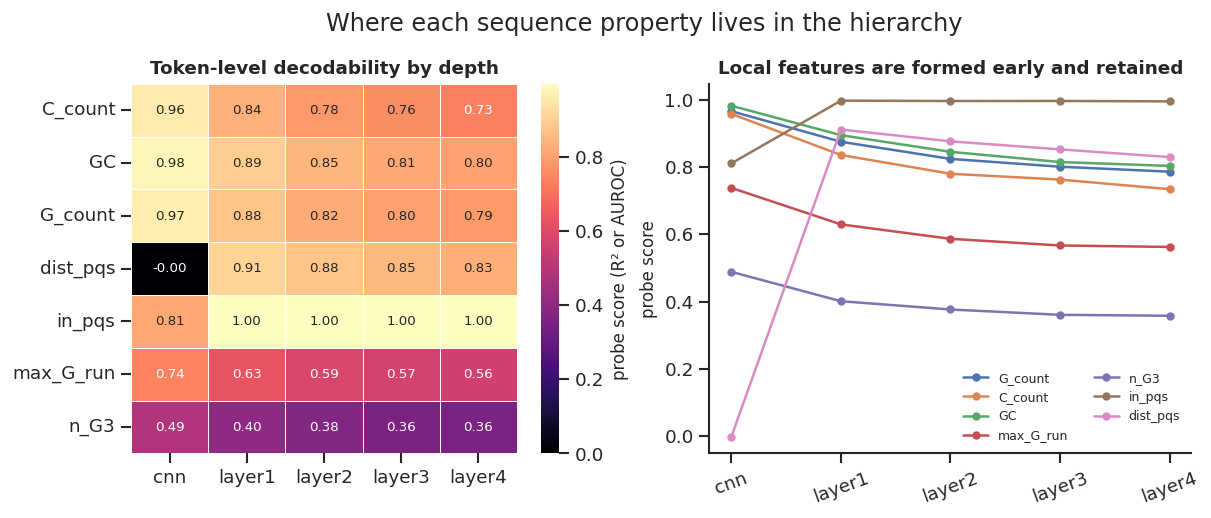

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.0))
piv = prb.pivot(index="prop", columns="layer", values="score")[LAYERS]
sns.heatmap(piv, cmap="magma", ax=axes[0], annot=True, fmt=".2f", annot_kws={"size":8},
            vmin=0, cbar_kws={"label":"probe score (R² or AUROC)"}, linewidths=.5, linecolor="w")
axes[0].set_title("Token-level decodability by depth"); axes[0].set_xlabel(""); axes[0].set_ylabel("")

for prop in PROPS:
    s = prb[prb["prop"] == prop]
    axes[1].plot(range(len(LAYERS)), s["score"], marker="o", ms=4, lw=1.5, label=prop)
axes[1].set_xticks(range(len(LAYERS))); axes[1].set_xticklabels(LAYERS, rotation=20)
axes[1].set_ylabel("probe score"); axes[1].legend(fontsize=7.5, ncol=2)
axes[1].set_title("Local features are formed early and retained")
fig.suptitle("Where each sequence property lives in the hierarchy", y=1.03)
save(fig, "fig3a_layer_probes"); plt.show()

### 4.2 Sequence-level: when does the class become linearly decodable?

The token probes ask about *local* features. The prediction is made from the **mean-pooled**
representation, so here we probe that same pooled vector for the actual target class. The
rise across depth localises where the integrated decision is assembled.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig3b_pooled_class_probe.png


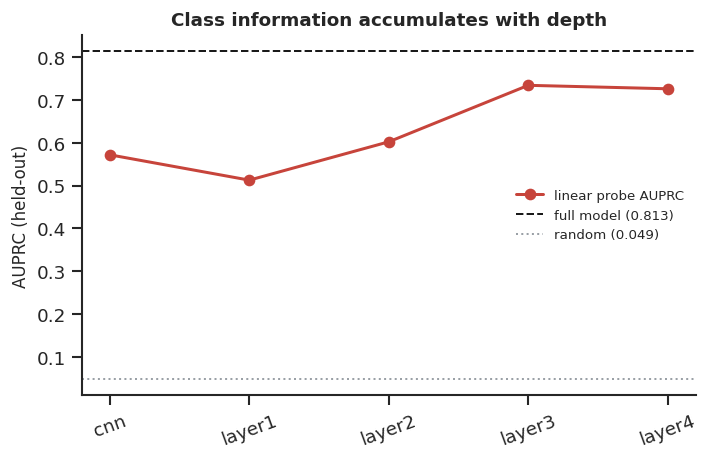

,layer,AUPRC,AUROC
0,cnn,0.5717,0.9432
1,layer1,0.5126,0.9672
2,layer2,0.6021,0.9781
3,layer3,0.7338,0.9807
4,layer4,0.7257,0.9809


In [37]:
ysel = D1["label"][sel]
rows = []
for lay in LAYERS:
    P = reps[lay].mean(1)                      # mean-pool, exactly as the model does
    sc = StandardScaler().fit(P[tr_i])
    m  = LogisticRegression(max_iter=2000, class_weight="balanced").fit(sc.transform(P[tr_i]), ysel[tr_i])
    s  = m.decision_function(sc.transform(P[te_i]))
    rows.append(dict(layer=lay, AUPRC=average_precision_score(ysel[te_i], s),
                     AUROC=roc_auc_score(ysel[te_i], s)))
POOL = pd.DataFrame(rows)
POOL.to_csv(OUT / "probe_pooled_class.csv", index=False)

fig, ax = plt.subplots(figsize=(6.6, 3.9))
ax.plot(range(len(LAYERS)), POOL["AUPRC"], marker="o", color=POS_C, lw=1.8, label="linear probe AUPRC")
full = average_precision_score(ysel[te_i], predict_logits(D1["seqs"][sel][te_i]))
ax.axhline(full, ls="--", color="k", lw=1.2, label=f"full model ({full:.3f})")
ax.axhline(ysel.mean(), ls=":", color=NEU_C, lw=1.2, label=f"random ({ysel.mean():.3f})")
ax.set_xticks(range(len(LAYERS))); ax.set_xticklabels(LAYERS, rotation=20)
ax.set_ylabel("AUPRC (held-out)"); ax.legend(fontsize=8)
ax.set_title("Class information accumulates with depth")
save(fig, "fig3b_pooled_class_probe"); plt.show()
POOL.round(4)

---
## 5. Attention analysis

> **Which elements does the Transformer connect?**

**This section is deliberately subordinate.** Attention weights are not explanations —
they are one component of a computation that also includes values, residual stream, and
MLPs. We use attention only to ask whether the model *links* the regions that sections 2–3
already proved causal.

> **Depends on §2.** This section reuses `idx_pos`, `idx_neg` and `imp_pos` from the
> mutagenesis run — §5.2 correlates attention against ISM importance, so §2 must have been
> executed (or its `results/ism_*.npz` cache present).

In [38]:
@torch.no_grad()
def get_attention(seqs, batch=128):
    """→ (N, layers, heads, 100, 100). Re-runs each encoder layer's self-attn manually."""
    all_A = []
    for i in range(0, len(seqs), batch):
        xb = torch.from_numpy(np.asarray(seqs[i:i+batch])).float().to(DEVICE)
        h  = model.seq_stem(xb).permute(0, 2, 1)
        h  = model.pe(h)
        per_layer = []
        for layer in model.seq_encoder.layers:
            # norm_first=True → self-attention sees the normed input
            hn = layer.norm1(h)
            _, A = layer.self_attn(hn, hn, hn, need_weights=True, average_attn_weights=False)
            per_layer.append(A.cpu())
            h = layer(h)                      # advance the true residual stream
        all_A.append(torch.stack(per_layer, 1))
    return torch.cat(all_A).numpy()

A_pos = get_attention(D1["seqs"][idx_pos[:100]])
A_neg = get_attention(D1["seqs"][idx_neg[:100]])
print("attention:", A_pos.shape, "(N, layer, head, query, key)")

attention: (100, 4, 4, 100, 100) (N, layer, head, query, key)


### 5.1 Attention distance — local or long-range heads?

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig4a_attention_distance.png


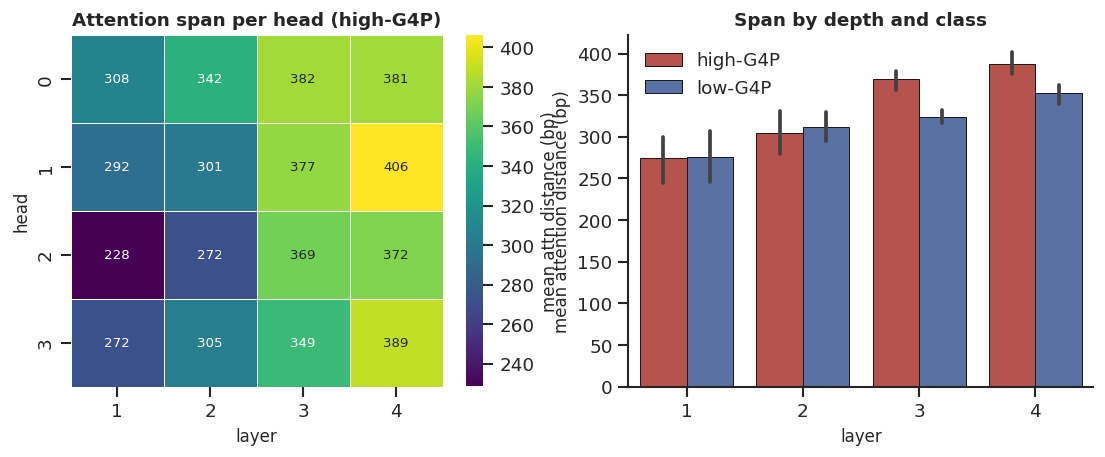

In [39]:
qi, ki = np.meshgrid(np.arange(N_TOK), np.arange(N_TOK), indexing="ij")
dist = np.abs(qi - ki)

rows = []
for name, A in [("high-G4P", A_pos), ("low-G4P", A_neg)]:
    for l in range(A.shape[1]):
        for h in range(A.shape[2]):
            w = A[:, l, h]                            # (N,100,100)
            md_ = (w * dist[None]).sum((1, 2)) / w.sum((1, 2))
            rows.append(dict(cls=name, layer=l+1, head=h, mean_dist=md_.mean()*STEM_K))
AD = pd.DataFrame(rows); AD.to_csv(OUT / "attention_distance.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
piv = AD[AD.cls == "high-G4P"].pivot(index="head", columns="layer", values="mean_dist")
sns.heatmap(piv, cmap="viridis", ax=axes[0], annot=True, fmt=".0f", annot_kws={"size":8},
            cbar_kws={"label":"mean attn distance (bp)"}, linewidths=.5, linecolor="w")
axes[0].set_title("Attention span per head (high-G4P)")

sns.barplot(data=AD, x="layer", y="mean_dist", hue="cls", ax=axes[1],
            palette=[POS_C, NEG_C], errorbar=("ci",95), edgecolor="k", linewidth=.6)
axes[1].set_ylabel("mean attention distance (bp)"); axes[1].legend(title="")
axes[1].set_title("Span by depth and class")
save(fig, "fig4a_attention_distance"); plt.show()

### 5.2 Does attention concentrate on the causally important tokens?

The one attention analysis that carries weight: correlate each token's **received
attention** with its **ISM importance**, per sequence. Attention is only informative here
insofar as it agrees with the causal measurement.

  layer 1: median ρ = +0.817
  layer 2: median ρ = +0.615
  layer 3: median ρ = -0.513
  layer 4: median ρ = -0.404
saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig4b_attention_vs_ism.png


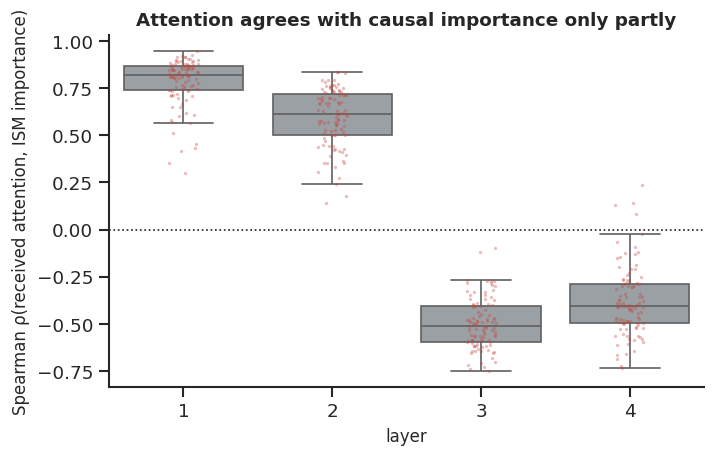

In [40]:
def tokenise_importance(imp_row):
    return imp_row.reshape(N_TOK, STEM_K).mean(1)

n_cmp = min(100, len(idx_pos))
corrs = []
for r in range(n_cmp):
    ti = tokenise_importance(imp_pos[r])
    for l in range(A_pos.shape[1]):
        recv = A_pos[r, l].mean(0).sum(0)          # summed over heads' queries
        rho = stats.spearmanr(ti, recv).correlation
        corrs.append(dict(layer=l+1, rho=rho))
AC = pd.DataFrame(corrs); AC.to_csv(OUT / "attention_vs_ism.csv", index=False)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
sns.boxplot(data=AC, x="layer", y="rho", ax=ax, color=NEU_C, showfliers=False, linewidth=1)
sns.stripplot(data=AC, x="layer", y="rho", ax=ax, color=POS_C, size=2, alpha=.35)
ax.axhline(0, color="k", ls=":", lw=1)
ax.set_ylabel("Spearman ρ(received attention, ISM importance)")
ax.set_title("Attention agrees with causal importance only partly")
for l, s in AC.groupby("layer")["rho"]:
    print(f"  layer {l}: median ρ = {s.median():+.3f}")
save(fig, "fig4b_attention_vs_ism"); plt.show()

### 5.3 PQS-anchored attention map

Averaged attention around the PQS, for the two classes.

saved → /home/brx8wc/G4/interp_seqonly/results/figures/fig4c_anchored_attention.png


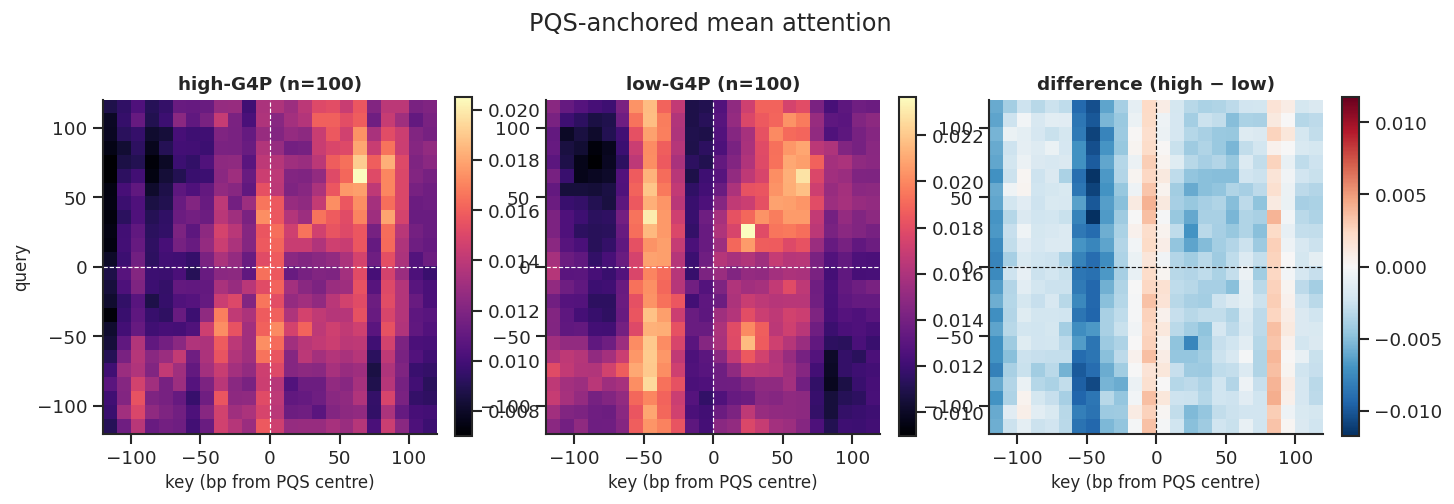

In [41]:
SPAN = 12   # tokens each side of the PQS-containing token

def anchored_map(A, indices):
    acc = np.zeros((2*SPAN, 2*SPAN)); n = 0
    for r, i in enumerate(indices[:len(A)]):
        c = int(((D1["pqs_start"][i] + D1["pqs_end"][i]) / 2) // STEM_K)
        lo, hi = c - SPAN, c + SPAN
        if lo < 0 or hi > N_TOK: continue
        acc += A[r].mean((0, 1))[lo:hi, lo:hi]; n += 1
    return acc / max(n, 1), n

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
Mp, np_ = anchored_map(A_pos, idx_pos)
Mn, nn_ = anchored_map(A_neg, idx_neg)
ext = [-SPAN*STEM_K, SPAN*STEM_K]*2
for ax, (M, t) in zip(axes[:2], [(Mp, f"high-G4P (n={np_})"), (Mn, f"low-G4P (n={nn_})")]):
    im = ax.imshow(M, cmap="magma", origin="lower", extent=ext)
    ax.axhline(0, color="w", lw=.7, ls="--"); ax.axvline(0, color="w", lw=.7, ls="--")
    ax.set_title(t); ax.set_xlabel("key (bp from PQS centre)"); ax.set_ylabel("query")
    plt.colorbar(im, ax=ax, fraction=.046)
d = Mp - Mn; v = np.abs(d).max()
im = axes[2].imshow(d, cmap=DIVERGE, origin="lower", vmin=-v, vmax=v, extent=ext)
axes[2].axhline(0, color="k", lw=.7, ls="--"); axes[2].axvline(0, color="k", lw=.7, ls="--")
axes[2].set_title("difference (high − low)"); axes[2].set_xlabel("key (bp from PQS centre)")
plt.colorbar(im, ax=axes[2], fraction=.046)
fig.suptitle("PQS-anchored mean attention", y=1.04)
save(fig, "fig4c_anchored_attention"); plt.show()